# Portfolio Risk Analytics

## Section 1 — Stock Selection & Justification

In [1]:
pip install yfinance pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
#Defining Stock Portfolio
stocks = {
    'AAPL': 'Technology',
    'MSFT': 'Technology',
    'JPM':  'Financials',
    'JNJ':  'Healthcare',
    'XOM':  'Energy',
    'AMZN': 'Consumer Discretionary',
    'NEE':  'Utilities',
    'CAT':  'Industrials',
    'PG':   'Consumer Staples',
    'BRK-B':'Financials'
}

tickers = list(stocks.keys())

In [4]:
import warnings
# warnings.filterwarnings('ignore')

START_DATE = '2001-01-01'
END_DATE   = '2025-12-31'
TRADING_DAYS = 252
RISK_FREE_RATE = 0.07  # 7% annual, approx current rate

# Download stock + benchmark data
raw = yf.download(tickers + ['^GSPC'], start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Separate benchmark
spy = raw['^GSPC']
prices = raw[tickers]

# Daily returns
returns = prices.pct_change().dropna()
spy_returns = spy.pct_change().dropna()

# Build justification table
records = []

for ticker in tickers:
    r = returns[ticker]

    ann_return = r.mean() * TRADING_DAYS
    ann_vol    = r.std() * np.sqrt(TRADING_DAYS)
    sharpe     = (ann_return - RISK_FREE_RATE) / ann_vol

    # Beta
    cov   = np.cov(r, spy_returns)[0][1]
    beta  = cov / spy_returns.var()

    # Treynor Ratio
    treynor = (ann_return - RISK_FREE_RATE) / beta

    # Sortino Ratio
    downside_returns = r[r < 0]
    downside_vol     = downside_returns.std() * np.sqrt(TRADING_DAYS)
    sortino          = (ann_return - RISK_FREE_RATE) / downside_vol

    # Jensen's Alpha
    market_return = spy_returns.mean() * TRADING_DAYS
    jensens_alpha = ann_return - (RISK_FREE_RATE + beta * (market_return - RISK_FREE_RATE))

    # Market cap (live fetch)
    info   = yf.Ticker(ticker).info
    mktcap = info.get('marketCap', np.nan)
    mktcap_bn = round(mktcap / 1e9, 1) if mktcap else 'N/A'

    records.append({
        'Ticker'          : ticker,
        'Sector'          : stocks[ticker],
        'Market Cap ($B)' : mktcap_bn,
        'Ann. Return (%)'  : round(ann_return * 100, 2),
        'Volatility (%)'  : round(ann_vol * 100, 2),
        'Beta'            : round(beta, 2),
        'Sharpe Ratio'    : round(sharpe, 2),
        'Sortino Ratio'   : round(sortino, 2),
        'Treynor Ratio'   : round(treynor, 4),
        "Jensen's Alpha"  : round(jensens_alpha * 100, 2)
    })

justification_df = pd.DataFrame(records).set_index('Ticker')

[*********************100%***********************]  11 of 11 completed


In [5]:
justification_df.style\
    .background_gradient(subset=['Ann. Return (%)'],  cmap='Blues')\
    .background_gradient(subset=['Volatility (%)'],   cmap='Blues')\
    .background_gradient(subset=['Sharpe Ratio'],     cmap='Blues')\
    .background_gradient(subset=['Sortino Ratio'],    cmap='Blues')\
    .background_gradient(subset=['Treynor Ratio'],    cmap='Blues')\
    .background_gradient(subset=["Jensen's Alpha"],   cmap='Blues')\
    .background_gradient(subset=['Beta'],             cmap='Blues')\
    .format({
        'Market Cap ($B)' : '{}',
        'Ann. Return (%)' : '{:.2f}%',
        'Volatility (%)'  : '{:.2f}%',
        'Beta'            : '{:.2f}',
        'Sharpe Ratio'    : '{:.2f}',
        'Sortino Ratio'   : '{:.2f}',
        'Treynor Ratio'   : '{:.2f}',
        "Jensen's Alpha"  : '{:.2f}%'
    })

,Sector,Market Cap ($B),Ann. Return (%),Volatility (%),Beta,Sharpe Ratio,Sortino Ratio,Treynor Ratio,Jensen's Alpha
Ticker,,,,,,,,,
AAPL,Technology,4514.7,34.71%,35.19%,1.12,0.79,1.13,0.25,25.92%
MSFT,Technology,3588.3,18.49%,28.43%,1.08,0.40,0.57,0.11,9.76%
JPM,Financials,934.6,17.53%,36.57%,1.40,0.29,0.39,0.08,8.29%
JNJ,Healthcare,651.3,9.96%,18.34%,0.52,0.16,0.22,0.06,2.14%
XOM,Energy,678.9,10.58%,25.98%,0.87,0.14,0.19,0.04,2.19%
AMZN,Consumer Discretionary,2789.7,33.50%,45.54%,1.22,0.58,0.85,0.22,24.55%
NEE,Utilities,174.5,14.82%,23.63%,0.64,0.33,0.44,0.12,6.80%
CAT,Industrials,380.6,20.37%,31.51%,1.14,0.42,0.60,0.12,11.55%
PG,Consumer Staples,336.3,9.60%,18.53%,0.51,0.14,0.19,0.05,1.78%


### Selection Rationale

#### Portfolio Composition
- **10 stocks** across **8 distinct sectors**, ensuring broad diversification.
- Two Technology stocks (AAPL, MSFT) and two Financials (JPM, BRK-B) are included,
  but they behave distinctly — JPM is a bank, BRK-B is a diversified holding company,
  and AAPL vs MSFT have different business models and risk profiles.

#### Return Leaders
- **AAPL (34.71%)** and **AMZN (33.50%)** are the strongest compounders over the period.
- **CAT (20.37%)** is a standout industrial performer, outpacing MSFT (18.49%).
- **JNJ (9.96%)** and **PG (9.60%)** are the lowest-return stocks but serve as stability anchors.

#### Risk Profile
- **Defensive stocks** (Beta < 1): JNJ (0.52), PG (0.51), BRK-B (0.67), NEE (0.64), XOM (0.87)
  — these cushion the portfolio during market downturns.
- **Aggressive stocks** (Beta > 1): AAPL (1.12), MSFT (1.08), AMZN (1.22), JPM (1.40), CAT (1.14)
  — these drive upside during bull markets.
- **JPM** has the highest Beta (1.40) and volatility (36.57%), making it the riskiest individual stock.
- **AMZN** has the highest raw volatility (45.54%) driven by its aggressive growth profile.

#### Risk-Adjusted Performance
- **AAPL** leads on all three ratios — Sharpe (0.79), Sortino (1.13), Treynor (0.25).
- **AMZN** is second best despite highest raw volatility (45.54%), justified by its outsized return.
- **CAT (0.42)** edges out MSFT (0.40) on Sharpe, making it the surprise risk-adjusted performer.
- **PG (0.14)** and **JNJ (0.16)** have the weakest Sharpe ratios — included for defensive
  diversification, not return generation.

#### Jensen's Alpha (Outperformance vs CAPM)
- **AAPL (25.92%)** and **AMZN (24.55%)** significantly outperformed what their Beta predicted.
- **CAT (11.55%)** delivered strong alpha for an industrial stock, rewarding risk taken.
- **PG (1.78%)** and **JNJ (2.14%)** barely beat CAPM expectations — confirms their role as
  stability plays rather than alpha generators.
- All 10 stocks show **positive Alpha**, meaning every stock added value beyond market expectations.

# Section 2 — Data Download & Return Calculation

In [6]:
START_DATE = '2001-01-01'
END_DATE   = '2025-12-31'

# Download adjusted closing prices
prices = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.head()

[*********************100%***********************]  10 of 10 completed

Data shape: (6286, 10)
Date range: 2001-01-02 to 2025-12-30


Ticker,AAPL,AMZN,BRK-B,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
2001-01-02,0.222453,0.693750,48.220001,12.329261,25.972275,21.064501,13.164427,3.956735,19.716164,19.666412
2001-01-03,0.244885,0.878125,46.700001,12.379181,25.144733,24.413710,14.549153,3.780721,18.742916,18.811342
2001-01-04,0.255167,0.775000,45.880001,12.961531,24.603634,25.076786,14.700902,3.555427,18.162106,18.287275
2001-01-05,0.244885,0.728125,44.980000,12.212796,24.921928,23.599905,14.909558,3.569509,18.821413,18.370033
2001-01-08,0.247689,0.746875,44.840000,12.179515,24.890097,23.750626,14.852652,3.587109,19.229546,18.287275


In [7]:
missing = prices.isnull().sum()
print("Missing values per stock:")
print(missing)

# Drop any remaining NaN rows
prices = prices.dropna()
print(f"\nClean data shape: {prices.shape}")

Missing values per stock:
Ticker
AAPL     0
AMZN     0
BRK-B    0
CAT      0
JNJ      0
JPM      0
MSFT     0
NEE      0
PG       0
XOM      0
dtype: int64

Clean data shape: (6286, 10)


In [8]:
# Simple returns
simple_returns = prices.pct_change().dropna()

# Log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

print("Simple Returns — first 5 rows:")
display(simple_returns.head())

print("\nLog Returns — first 5 rows:")
display(log_returns.head())

Simple Returns — first 5 rows:


Ticker,AAPL,AMZN,BRK-B,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
2001-01-03,0.100842,0.265766,-0.031522,0.004049,-0.031862,0.158998,0.105187,-0.044485,-0.049363,-0.043479
2001-01-04,0.041985,-0.117438,-0.017559,0.047043,-0.021519,0.027160,0.010430,-0.059590,-0.030988,-0.027859
2001-01-05,-0.040294,-0.060484,-0.019616,-0.057766,0.012937,-0.058894,0.014193,0.003961,0.036301,0.004525
2001-01-08,0.011449,0.025751,-0.003112,-0.002725,-0.001277,0.006386,-0.003817,0.004931,0.021684,-0.004505
2001-01-09,0.037737,0.096234,-0.018733,-0.001366,0.007033,-0.011421,0.058749,-0.007851,-0.025306,-0.010558



Log Returns — first 5 rows:


Ticker,AAPL,AMZN,BRK-B,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
2001-01-03,0.096075,0.235677,-0.032030,0.004041,-0.032381,0.147556,0.100015,-0.045504,-0.050623,-0.044452
2001-01-04,0.041128,-0.124926,-0.017715,0.045970,-0.021754,0.026798,0.010376,-0.061440,-0.031479,-0.028255
2001-01-05,-0.041128,-0.062390,-0.019811,-0.059502,0.012854,-0.060700,0.014094,0.003953,0.035658,0.004515
2001-01-08,0.011384,0.025425,-0.003117,-0.002729,-0.001278,0.006366,-0.003824,0.004918,0.021453,-0.004515
2001-01-09,0.037043,0.091881,-0.018911,-0.001367,0.007008,-0.011487,0.057088,-0.007882,-0.025632,-0.010614


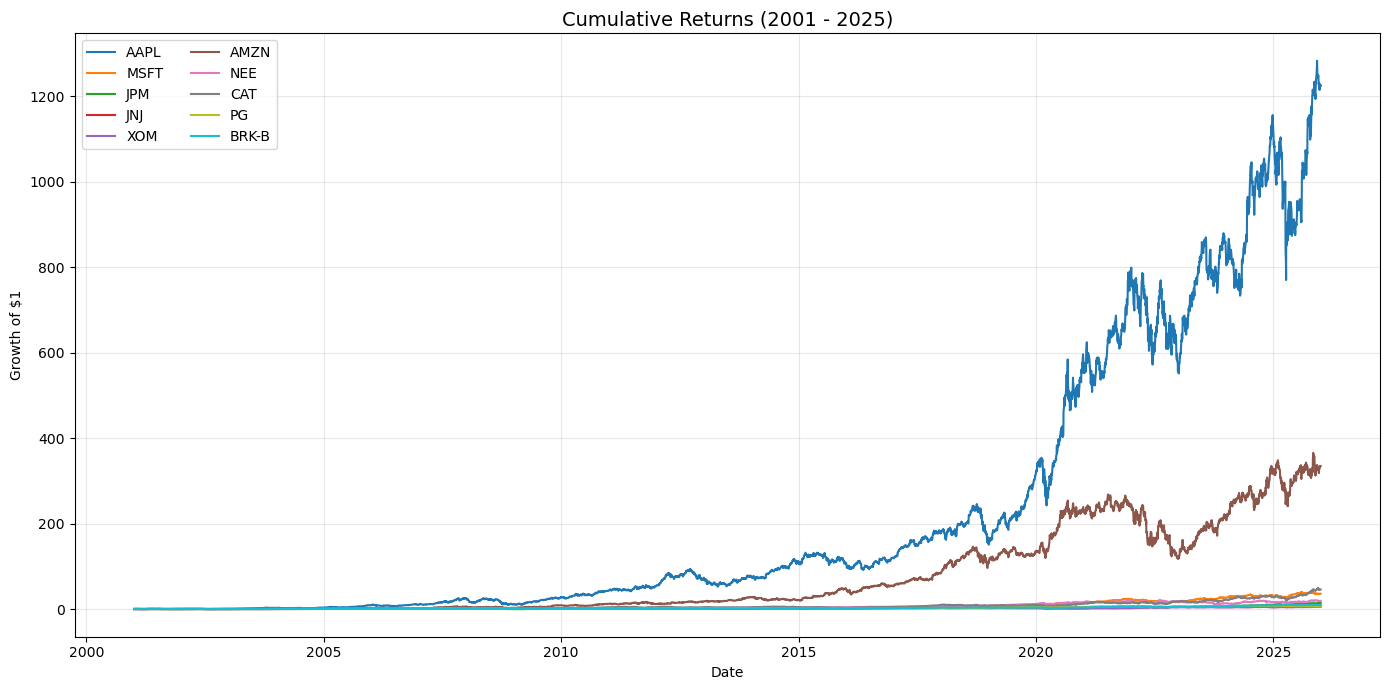

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


cumulative_returns = (1 + simple_returns).cumprod()

plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title('Cumulative Returns (2001 - 2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.xticks(
    pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'),
    labels=[str(y) for y in range(2000, 2026, 5)]
)
plt.tight_layout()
plt.show()

# Section 3 — Individual Stock Metrics

In [10]:
# Using justification_df from Section 1
metrics_df = justification_df.drop(columns=['Market Cap ($B)'])

# Calculate Max Drawdown
def max_drawdown(return_series):
    cumulative  = (1 + return_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

# Add Max Drawdown to metrics_df
metrics_df['Max Drawdown (%)'] = [
    round(max_drawdown(simple_returns[ticker]) * 100, 2)
    for ticker in tickers
]

metrics_df.style\
    .background_gradient(subset=['Ann. Return (%)'],  cmap='Blues')\
    .background_gradient(subset=['Volatility (%)'],   cmap='Blues')\
    .background_gradient(subset=['Sharpe Ratio'],     cmap='Blues')\
    .background_gradient(subset=['Sortino Ratio'],    cmap='Blues')\
    .background_gradient(subset=['Treynor Ratio'],    cmap='Blues')\
    .background_gradient(subset=["Jensen's Alpha"],   cmap='Blues')\
    .background_gradient(subset=['Beta'],             cmap='Blues')\
    .background_gradient(subset=['Max Drawdown (%)'], cmap='Blues')\
    .format({
        'Ann. Return (%)' : '{:.2f}%',
        'Volatility (%)'  : '{:.2f}%',
        'Beta'            : '{:.2f}',
        'Sharpe Ratio'    : '{:.2f}',
        'Sortino Ratio'   : '{:.2f}',
        'Treynor Ratio'   : '{:.4f}',
        "Jensen's Alpha"  : '{:.2f}%',
        'Max Drawdown (%)': '{:.2f}%'
    })

,Sector,Ann. Return (%),Volatility (%),Beta,Sharpe Ratio,Sortino Ratio,Treynor Ratio,Jensen's Alpha,Max Drawdown (%)
Ticker,,,,,,,,,
AAPL,Technology,34.71%,35.19%,1.12,0.79,1.13,0.2474,25.92%,-60.87%
MSFT,Technology,18.49%,28.43%,1.08,0.40,0.57,0.1061,9.76%,-57.94%
JPM,Financials,17.53%,36.57%,1.40,0.29,0.39,0.0751,8.29%,-70.32%
JNJ,Healthcare,9.96%,18.34%,0.52,0.16,0.22,0.0575,2.14%,-35.88%
XOM,Energy,10.58%,25.98%,0.87,0.14,0.19,0.0412,2.19%,-62.40%
AMZN,Consumer Discretionary,33.50%,45.54%,1.22,0.58,0.85,0.2166,24.55%,-72.71%
NEE,Utilities,14.82%,23.63%,0.64,0.33,0.44,0.1222,6.80%,-47.81%
CAT,Industrials,20.37%,31.51%,1.14,0.42,0.60,0.1176,11.55%,-73.43%
PG,Consumer Staples,9.60%,18.53%,0.51,0.14,0.19,0.0506,1.78%,-39.01%


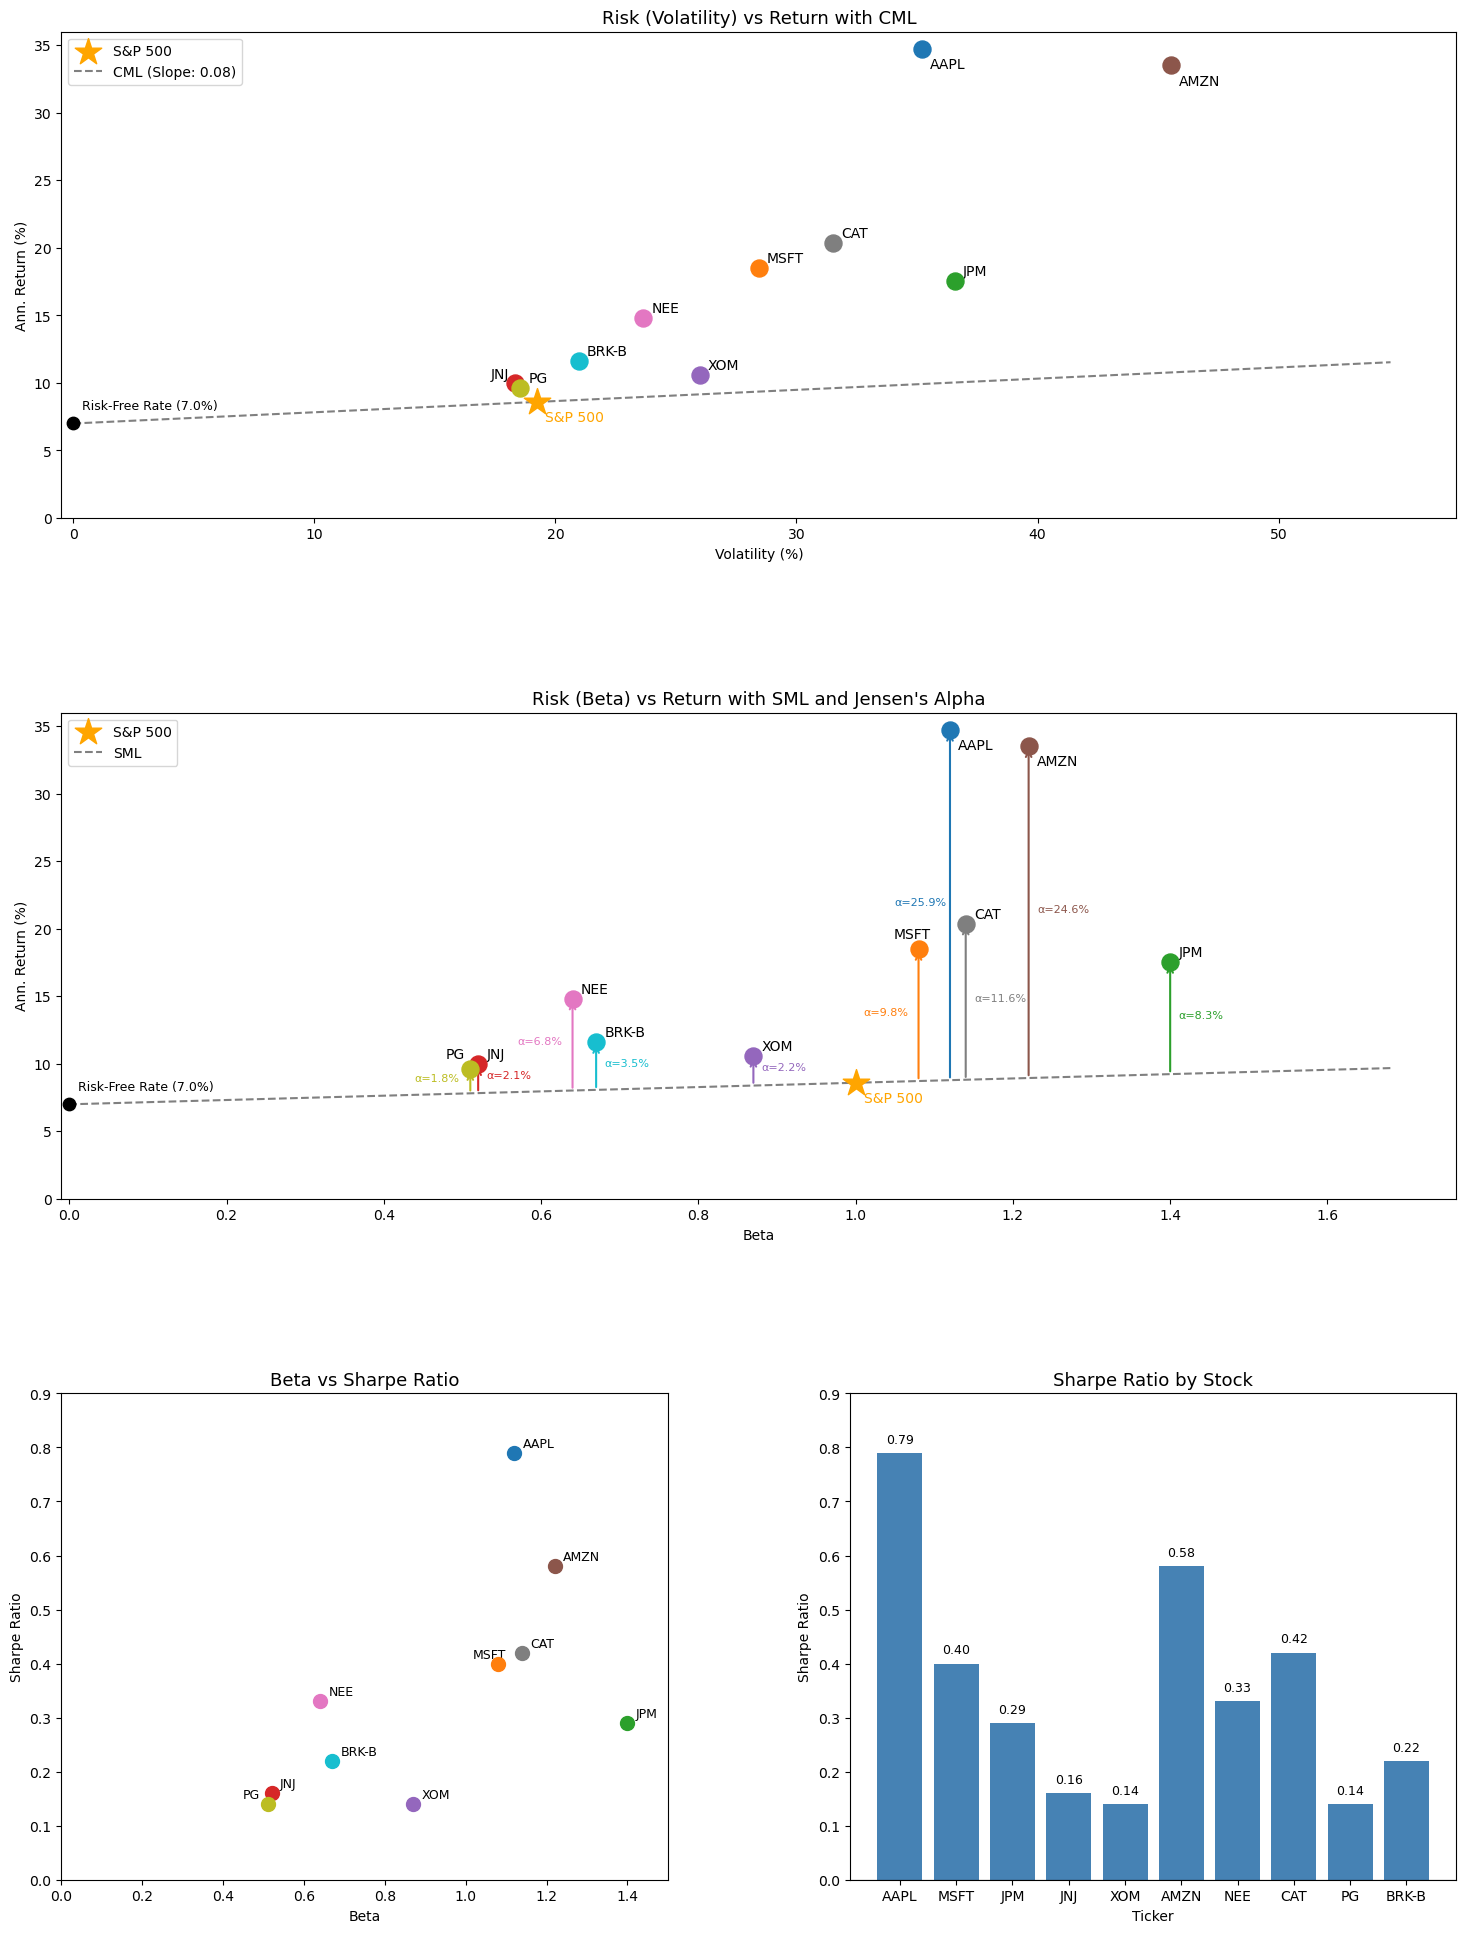

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(18, 24))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── ROW 1: Volatility vs Return + CML (full width) ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])

for ticker in tickers:
    x = metrics_df.loc[ticker, 'Volatility (%)']
    y = metrics_df.loc[ticker, 'Ann. Return (%)']
    ax1.scatter(x, y, s=150, zorder=5)
    if ticker == 'JNJ':
        ax1.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(-18, 4), fontsize=10)
    elif ticker in ['AAPL', 'AMZN']:
        ax1.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(6, -14), fontsize=10)
    else:
        ax1.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(6, 4), fontsize=10)

spy_ann_return = spy_returns.squeeze().mean() * TRADING_DAYS * 100
spy_ann_vol    = spy_returns.squeeze().std() * np.sqrt(TRADING_DAYS) * 100

ax1.scatter(spy_ann_vol, spy_ann_return,
    marker='*', s=400, color='orange', zorder=6, label='S&P 500')
ax1.annotate('S&P 500', (spy_ann_vol, spy_ann_return),
    textcoords='offset points', xytext=(6, -14), fontsize=10, color='orange')

rf        = RISK_FREE_RATE * 100
cml_slope = (spy_ann_return - rf) / spy_ann_vol
x_max     = metrics_df['Volatility (%)'].max() * 1.2
x_range   = np.linspace(0, x_max, 100)
cml_y     = rf + cml_slope * x_range

ax1.plot(x_range, cml_y, linestyle='--', color='gray', linewidth=1.5,
    label=f'CML (Slope: {cml_slope:.2f})')
ax1.scatter(0, rf, marker='o', color='black', s=80, zorder=6)
ax1.annotate(f'Risk-Free Rate ({rf:.1f}%)', (0, rf),
    textcoords='offset points', xytext=(6, 10), fontsize=9, color='black')

ax1.set_title('Risk (Volatility) vs Return with CML', fontsize=13)
ax1.set_xlabel('Volatility (%)')
ax1.set_ylabel('Ann. Return (%)')
ax1.set_ylim(bottom=0, top=36)
ax1.set_xlim(left=-0.5)
ax1.legend(loc='upper left')
ax1.grid(False)

# ── ROW 2: Beta vs Return + SML + Alpha lines (full width) ──────────────────
ax2 = fig.add_subplot(gs[1, :])

# Get default colour cycle to match marker colours
prop_cycle = plt.rcParams['axes.prop_cycle']
colors_cycle = prop_cycle.by_key()['color']
ticker_colors = {ticker: colors_cycle[i % len(colors_cycle)] for i, ticker in enumerate(tickers)}

for ticker in tickers:
    x = metrics_df.loc[ticker, 'Beta']
    y = metrics_df.loc[ticker, 'Ann. Return (%)']
    ax2.scatter(x, y, s=150, zorder=5, color=ticker_colors[ticker])
    if ticker in ['PG', 'MSFT']:
        ax2.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(-18, 8), fontsize=10)
    elif ticker in ['AAPL', 'AMZN']:
        ax2.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(6, -14), fontsize=10)
    else:
        ax2.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(6, 4), fontsize=10)

ax2.scatter(1, spy_ann_return,
    marker='*', s=400, color='orange', zorder=6, label='S&P 500')
ax2.annotate('S&P 500', (1, spy_ann_return),
    textcoords='offset points', xytext=(6, -14), fontsize=10, color='orange')

sml_x = np.linspace(0, metrics_df['Beta'].max() * 1.2, 100)
sml_y = rf + sml_x * (spy_ann_return - rf)
ax2.plot(sml_x, sml_y, linestyle='--', color='gray', linewidth=1.5, label='SML')

ax2.scatter(0, rf, marker='o', color='black', s=80, zorder=6)
ax2.annotate(f'Risk-Free Rate ({rf:.1f}%)', (0, rf),
    textcoords='offset points', xytext=(6, 10), fontsize=9, color='black')

# Alpha left label tickers
alpha_left = ['PG', 'NEE', 'MSFT', 'AAPL']

for ticker in tickers:
    beta_val      = metrics_df.loc[ticker, 'Beta']
    actual_return = metrics_df.loc[ticker, 'Ann. Return (%)']
    expected_ret  = rf + beta_val * (spy_ann_return - rf)
    alpha         = metrics_df.loc[ticker, "Jensen's Alpha"]
    color         = ticker_colors[ticker]
    ax2.annotate('',
        xy=(beta_val, actual_return),
        xytext=(beta_val, expected_ret),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5)
    )
    offset = (-40, 0) if ticker in alpha_left else (6, 0)
    ax2.annotate(f'α={alpha:.1f}%', (beta_val, (actual_return + expected_ret) / 2),
        textcoords='offset points', xytext=offset, fontsize=8, color=color
    )

ax2.set_title("Risk (Beta) vs Return with SML and Jensen's Alpha", fontsize=13)
ax2.set_xlabel('Beta')
ax2.set_ylabel('Ann. Return (%)')
ax2.set_ylim(bottom=0, top=36)
ax2.set_xlim(left=-0.01)
ax2.legend(loc='upper left')
ax2.grid(False)

# ── ROW 3: Beta vs Sharpe Scatter ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])

for ticker in tickers:
    x = metrics_df.loc[ticker, 'Beta']
    y = metrics_df.loc[ticker, 'Sharpe Ratio']
    ax3.scatter(x, y, s=100, zorder=5)
    if ticker in ['PG','MSFT']:
        ax3.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(-18, 4), fontsize=9)
    else:
        ax3.annotate(ticker, (x, y),
            textcoords='offset points', xytext=(6, 4), fontsize=9)

ax3.set_title('Beta vs Sharpe Ratio', fontsize=13)
ax3.set_xlabel('Beta')
ax3.set_ylabel('Sharpe Ratio')
ax3.set_xlim(left=0, right=1.5)
ax3.set_ylim(bottom=0, top=0.9)
ax3.grid(False)

ax4 = fig.add_subplot(gs[2, 1])
colors_sharpe = ['steelblue' if x > 0 else 'red' for x in metrics_df['Sharpe Ratio']]
bars4 = ax4.bar(metrics_df.index, metrics_df['Sharpe Ratio'], color=colors_sharpe)
ax4.set_title('Sharpe Ratio by Stock', fontsize=13)
ax4.set_xlabel('Ticker')
ax4.set_ylabel('Sharpe Ratio')
ax4.set_ylim(bottom=0, top=0.9)
ax4.axhline(0, color='black', linewidth=0.8)
for bar in bars4:
    height = bar.get_height()
    ax4.annotate(f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom', fontsize=9
    )
ax4.grid(False)

plt.show()


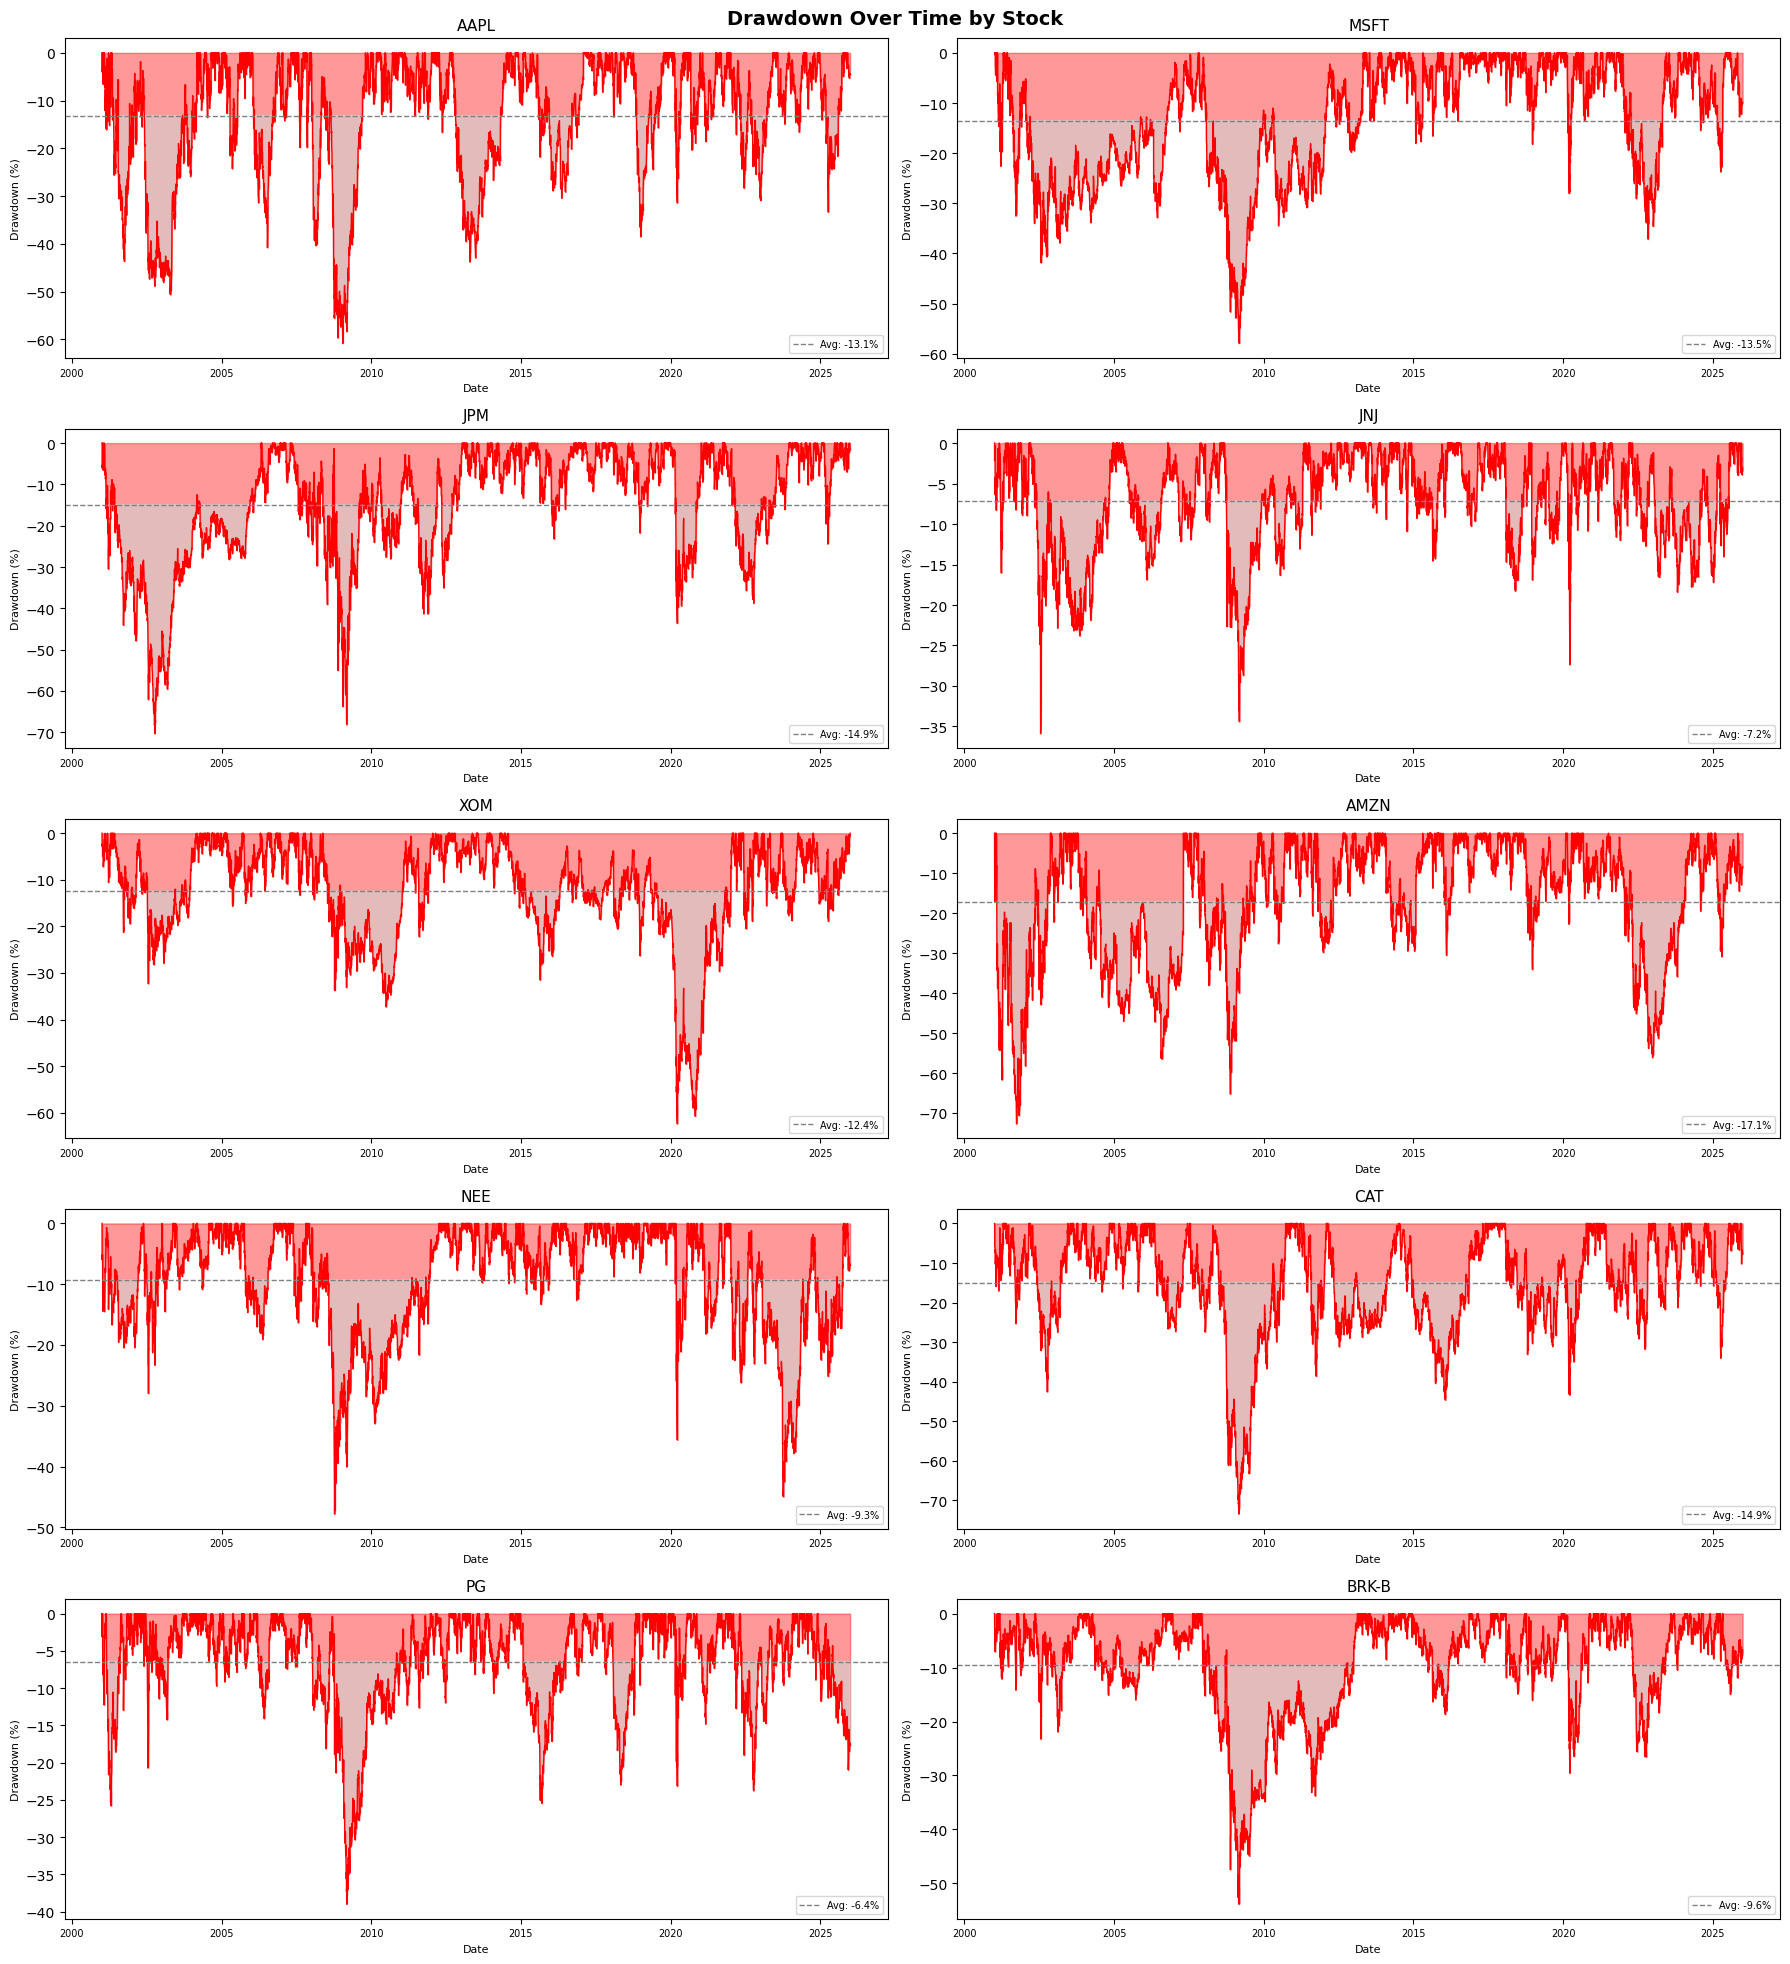

In [12]:
# ── Drawdown Over Time — Facet Grid ───────────────────────────────────
fig_a, axes_a = plt.subplots(5, 2, figsize=(18, 20))
axes_a = axes_a.flatten()

for i, ticker in enumerate(tickers):
    cumulative  = (1 + simple_returns[ticker]).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max * 100

    axes_a[i].fill_between(drawdown.index, drawdown, 0, alpha=0.4, color='red')
    axes_a[i].plot(drawdown.index, drawdown, color='red', linewidth=1)
    # Calculate average drawdown
    avg_drawdown = drawdown.mean()

    # Draw average line
    axes_a[i].axhline(avg_drawdown, color='grey', linewidth=1, 
        linestyle='--', label=f'Avg: {avg_drawdown:.1f}%')

    # Shade area where drawdown exceeds average
    axes_a[i].fill_between(drawdown.index, drawdown, avg_drawdown,
        where=(drawdown < avg_drawdown),
        color='lightgrey', alpha=0.6)

    axes_a[i].legend(fontsize=7, loc='lower right')
    axes_a[i].set_title(f'{ticker}', fontsize=11)
    axes_a[i].set_xlabel('Date', fontsize=8)
    axes_a[i].set_ylabel('Drawdown (%)', fontsize=8)
    axes_a[i].set_xticks(pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'))
    axes_a[i].set_xticklabels([str(y) for y in range(2000, 2026, 5)], fontsize=7)
    axes_a[i].grid(False)

fig_a.suptitle('Drawdown Over Time by Stock', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

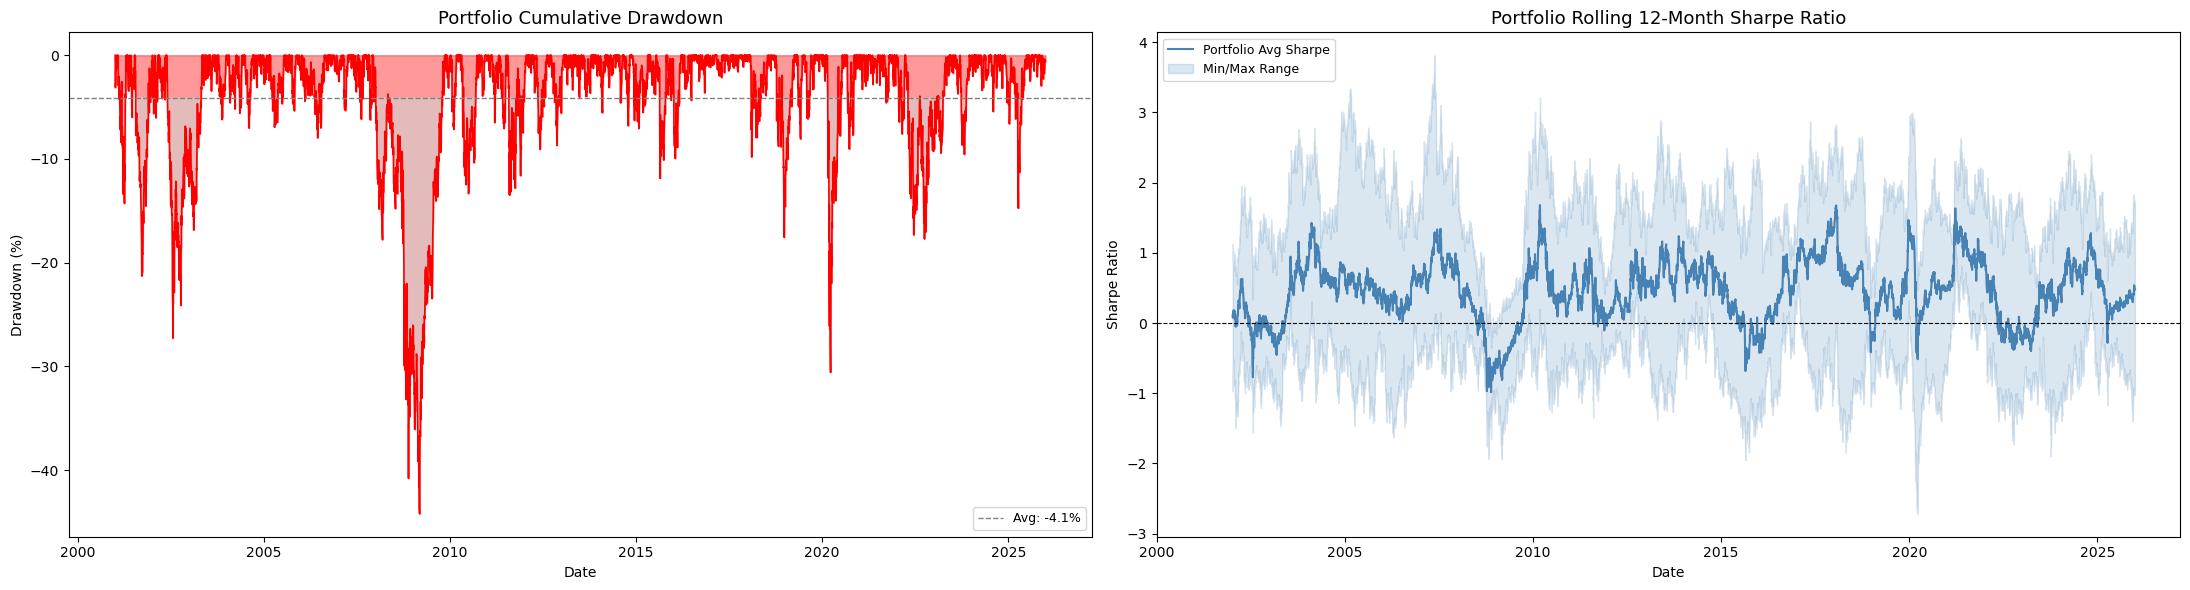

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# ── Left: Portfolio Cumulative Drawdown ──────────────────────────────────────
ax_dd = axes[0]

# Equal weighted portfolio daily returns
portfolio_returns    = simple_returns.mean(axis=1)
portfolio_cumulative = (1 + portfolio_returns).cumprod()
portfolio_rolling_max= portfolio_cumulative.cummax()
portfolio_drawdown   = (portfolio_cumulative - portfolio_rolling_max) / portfolio_rolling_max * 100

ax_dd.fill_between(portfolio_drawdown.index, portfolio_drawdown, 0,
    color='red', alpha=0.4)
ax_dd.plot(portfolio_drawdown.index, portfolio_drawdown,
    color='red', linewidth=1.2)
ax_dd.axhline(portfolio_drawdown.mean(), color='grey', linewidth=1,
    linestyle='--', label=f'Avg: {portfolio_drawdown.mean():.1f}%')
ax_dd.fill_between(portfolio_drawdown.index, portfolio_drawdown, portfolio_drawdown.mean(),
    where=(portfolio_drawdown < portfolio_drawdown.mean()),
    color='lightgrey', alpha=0.6)

ax_dd.set_title('Portfolio Cumulative Drawdown', fontsize=13)
ax_dd.set_xlabel('Date')
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.legend(loc='lower right', fontsize=9)
ax_dd.set_xticks(pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'))
ax_dd.set_xticklabels([str(y) for y in range(2000, 2026, 5)])
ax_dd.grid(False)

# ── Right: Portfolio Average Rolling Sharpe ───────────────────────────────────
ax_sharpe = axes[1]

rolling_sharpe = simple_returns.rolling(window=252).apply(
    lambda x: (x.mean() * TRADING_DAYS - RISK_FREE_RATE) / (x.std() * np.sqrt(TRADING_DAYS))
).dropna()

portfolio_sharpe_mean = rolling_sharpe.mean(axis=1)
portfolio_sharpe_min  = rolling_sharpe.min(axis=1)
portfolio_sharpe_max  = rolling_sharpe.max(axis=1)

ax_sharpe.plot(portfolio_sharpe_mean.index, portfolio_sharpe_mean,
    color='steelblue', linewidth=1.5, label='Portfolio Avg Sharpe')
ax_sharpe.fill_between(portfolio_sharpe_mean.index,
    portfolio_sharpe_min, portfolio_sharpe_max,
    color='steelblue', alpha=0.2, label='Min/Max Range')
ax_sharpe.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax_sharpe.set_title('Portfolio Rolling 12-Month Sharpe Ratio', fontsize=13)
ax_sharpe.set_xlabel('Date')
ax_sharpe.set_ylabel('Sharpe Ratio')
ax_sharpe.legend(loc='upper left', fontsize=9)
ax_sharpe.set_xticks(pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'))
ax_sharpe.set_xticklabels([str(y) for y in range(2000, 2026, 5)])
ax_sharpe.grid(False)

plt.tight_layout()
plt.show()

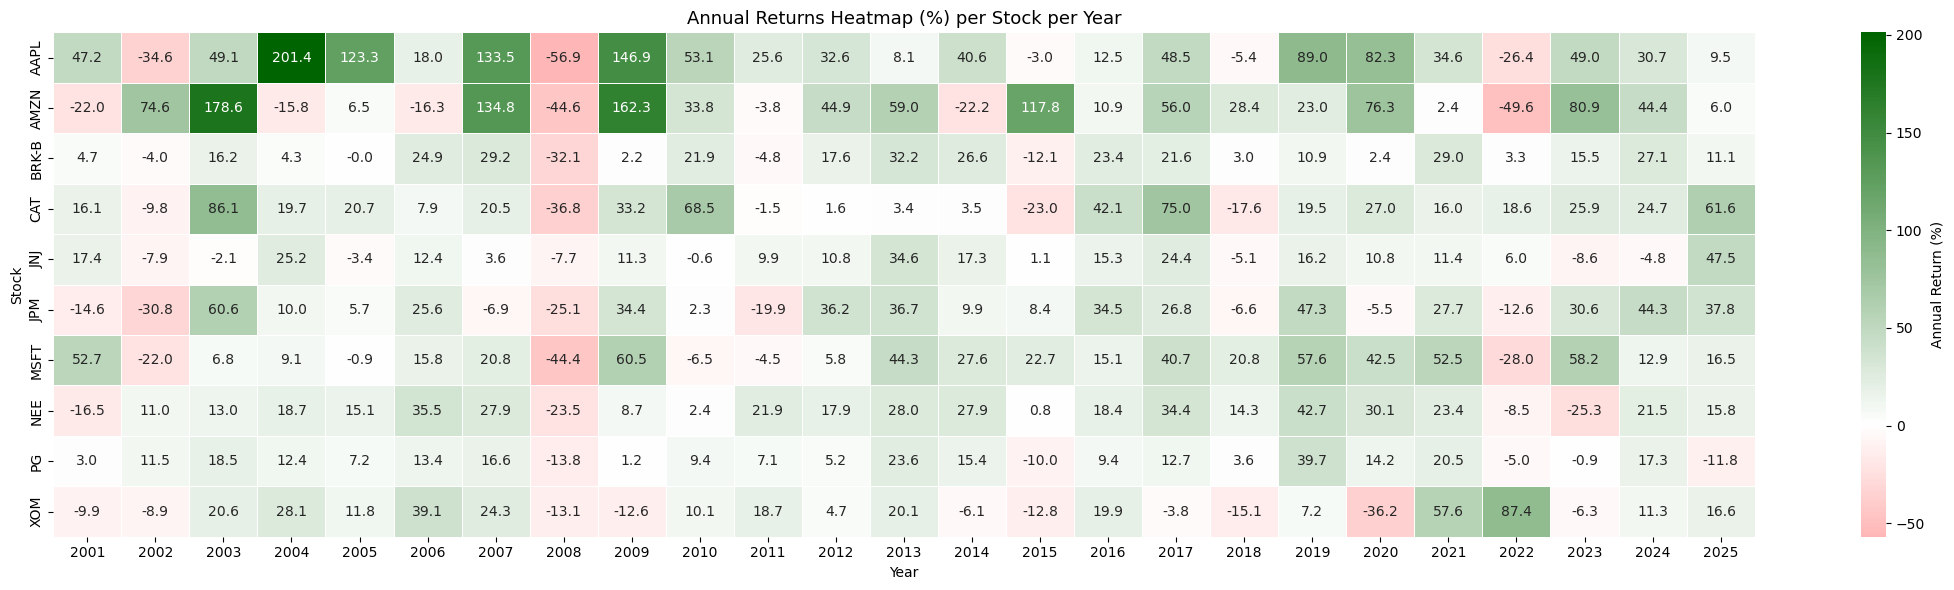

In [14]:
fig, ax8 = plt.subplots(figsize=(22, 6))

annual_returns = simple_returns.copy()
annual_returns.index = pd.to_datetime(annual_returns.index)
annual_returns = annual_returns.resample('YE').apply(
    lambda x: (1 + x).prod() - 1
) * 100
annual_returns.index = annual_returns.index.year

from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_green', ['#FF0000', 'white', 'darkgreen'], N=256
)

sns.heatmap(
    annual_returns.T,
    annot=True, fmt='.1f',
    cmap=custom_cmap, center=0,
    linewidths=0.5,
    ax=ax8,
    cbar_kws={'label': 'Annual Return (%)'}
)
ax8.set_title('Annual Returns Heatmap (%) per Stock per Year', fontsize=13)
ax8.set_xlabel('Year')
ax8.set_ylabel('Stock')

plt.tight_layout()
plt.show()

## Section 4 — Portfolio Construction (Equal Weights)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Equal weights
n_stocks        = len(tickers)
equal_weights   = np.array([1 / n_stocks] * n_stocks)

print("Equal Weights:")
for ticker, w in zip(tickers, equal_weights):
    print(f"  {ticker}: {w*100:.1f}%")

# Daily portfolio returns (weighted sum of individual returns)
portfolio_returns = simple_returns.dot(equal_weights)

print(f"\nPortfolio Daily Returns — first 5:")
print(portfolio_returns.head())

Equal Weights:
  AAPL: 10.0%
  MSFT: 10.0%
  JPM: 10.0%
  JNJ: 10.0%
  XOM: 10.0%
  AMZN: 10.0%
  NEE: 10.0%
  CAT: 10.0%
  PG: 10.0%
  BRK-B: 10.0%

Portfolio Daily Returns — first 5:
2001-01-03    0.043413
2001-01-04   -0.014834
2001-01-05   -0.016514
2001-01-08    0.005477
2001-01-09    0.012452
dtype: float64


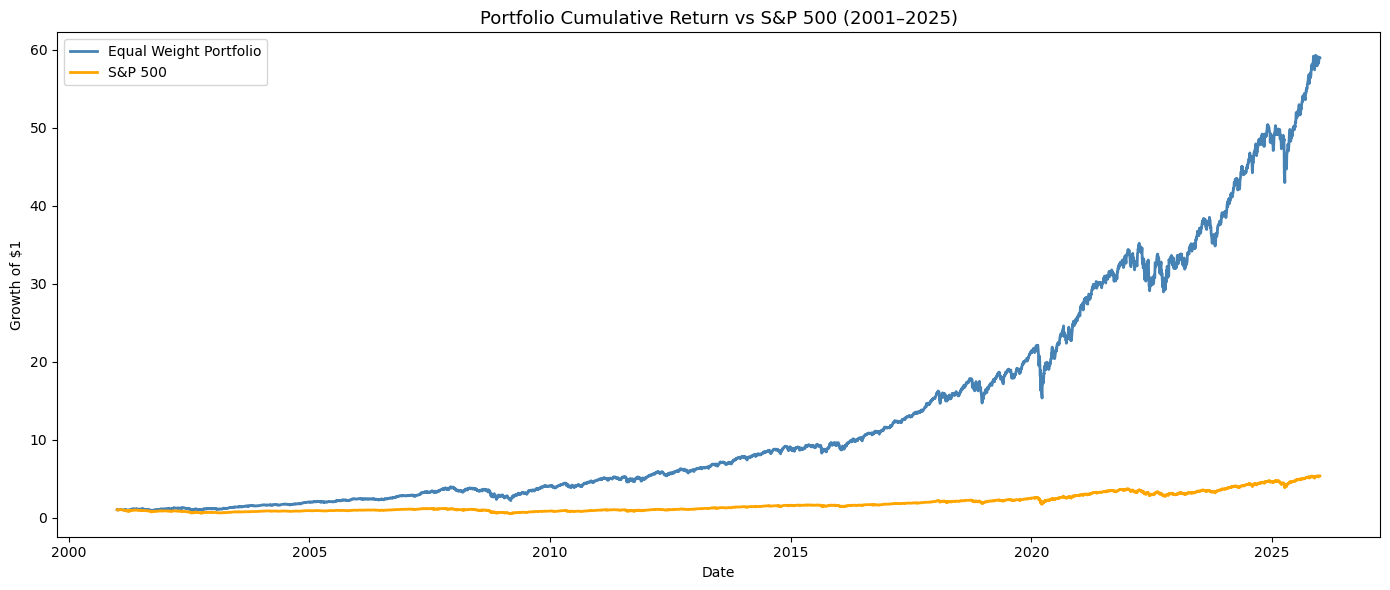

In [16]:
# Cumulative returns
portfolio_cumulative = (1 + portfolio_returns).cumprod()
spy_cumulative       = (1 + spy_returns.squeeze()).cumprod()

# Align spy to portfolio index
spy_cumulative = spy_cumulative.reindex(portfolio_cumulative.index)

plt.figure(figsize=(14, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative,
    color='steelblue', linewidth=2, label='Equal Weight Portfolio')
plt.plot(spy_cumulative.index, spy_cumulative,
    color='orange', linewidth=2, label='S&P 500')

plt.title('Portfolio Cumulative Return vs S&P 500 (2001–2025)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(loc='upper left')
plt.xticks(pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'),
    labels=[str(y) for y in range(2000, 2026, 5)])
plt.grid(False)
plt.tight_layout()
plt.show()

In [17]:
TRADING_DAYS   = 252
RISK_FREE_RATE = 0.05

# ── Core Metrics ─────────────────────────────────────────────────────────────
port_ann_return = portfolio_returns.mean() * TRADING_DAYS
port_ann_vol    = portfolio_returns.std() * np.sqrt(TRADING_DAYS)
port_sharpe     = (port_ann_return - RISK_FREE_RATE) / port_ann_vol

# Sortino
downside        = portfolio_returns[portfolio_returns < 0]
downside_vol    = downside.std() * np.sqrt(TRADING_DAYS)
port_sortino    = (port_ann_return - RISK_FREE_RATE) / downside_vol

# Beta & Treynor
spy_ret_aligned = spy_returns.squeeze().reindex(portfolio_returns.index).dropna()
port_aligned    = portfolio_returns.reindex(spy_ret_aligned.index)
cov             = np.cov(port_aligned, spy_ret_aligned)[0][1]
port_beta       = cov / spy_ret_aligned.var()
port_treynor    = (port_ann_return - RISK_FREE_RATE) / port_beta

# Jensen's Alpha
market_return   = spy_ret_aligned.mean() * TRADING_DAYS
port_alpha      = port_ann_return - (RISK_FREE_RATE + port_beta * (market_return - RISK_FREE_RATE))

# Excess Return vs S&P 500
spy_ann_return  = spy_ret_aligned.mean() * TRADING_DAYS
excess_return   = port_ann_return - spy_ann_return

# Drawdown series
cumulative      = (1 + portfolio_returns).cumprod()
rolling_max     = cumulative.cummax()
drawdown_series = (cumulative - rolling_max) / rolling_max * 100

# Max Drawdown
port_max_dd     = drawdown_series.min()

# Average Drawdown
port_avg_dd     = drawdown_series[drawdown_series < 0].mean()

# Max Drawdown Duration
in_drawdown     = drawdown_series < 0
drawdown_groups = (in_drawdown != in_drawdown.shift()).cumsum()
drawdown_duration = in_drawdown.groupby(drawdown_groups).sum()
port_max_dd_dur = drawdown_duration.max()

# Calmar Ratio
port_calmar     = port_ann_return / abs(port_max_dd / 100)

# Ulcer Index
port_ulcer      = np.sqrt((drawdown_series[drawdown_series < 0] ** 2).mean())

# Pain Ratio
port_pain       = port_ann_return / (port_ulcer / 100)

# Win Rate
port_win_rate   = (portfolio_returns > 0).sum() / len(portfolio_returns) * 100

# Best & Worst Year
annual_port     = portfolio_returns.copy()
annual_port.index = pd.to_datetime(annual_port.index)
annual_port     = annual_port.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
best_year       = annual_port.idxmax().year
best_year_ret   = annual_port.max()
worst_year      = annual_port.idxmin().year
worst_year_ret  = annual_port.min()

# Omega Ratio
threshold       = RISK_FREE_RATE / TRADING_DAYS
gains           = portfolio_returns[portfolio_returns > threshold] - threshold
losses          = threshold - portfolio_returns[portfolio_returns < threshold]
port_omega      = gains.sum() / losses.sum()

# ── Table 1: Return Metrics ───────────────────────────────────────────────────
table1 = pd.DataFrame({
    'Metric': [
        'Ann. Return (%)',
        'Best Year',
        'Worst Year',
        'Win Rate (%)',
        'Excess Return vs S&P 500 (%)'
    ],
    'Value': [
        f'{port_ann_return * 100:.2f}%',
        f'{best_year} ({best_year_ret:.1f}%)',
        f'{worst_year} ({worst_year_ret:.1f}%)',
        f'{port_win_rate:.1f}%',
        f'{excess_return * 100:.2f}%'
    ]
})

# ── Table 2: Risk Metrics ─────────────────────────────────────────────────────
table2 = pd.DataFrame({
    'Metric': [
        'Volatility (%)',
        'Beta',
        'Max Drawdown (%)',
        'Average Drawdown (%)',
        'Max Drawdown Duration (days)',
        'Calmar Ratio',
        'Ulcer Index'
    ],
    'Value': [
        f'{port_ann_vol * 100:.2f}%',
        f'{port_beta:.2f}',
        f'{port_max_dd:.2f}%',
        f'{port_avg_dd:.2f}%',
        f'{port_max_dd_dur}',
        f'{port_calmar:.2f}',
        f'{port_ulcer:.2f}'
    ]
})

# ── Table 3: Risk-Adjusted Metrics ───────────────────────────────────────────
table3 = pd.DataFrame({
    'Metric': [
        'Sharpe Ratio',
        'Sortino Ratio',
        'Treynor Ratio',
        "Jensen's Alpha (%)",
        'Omega Ratio',
        'Pain Ratio'
    ],
    'Value': [
        f'{port_sharpe:.2f}',
        f'{port_sortino:.2f}',
        f'{port_treynor:.4f}',
        f'{port_alpha * 100:.2f}%',
        f'{port_omega:.2f}',
        f'{port_pain:.2f}'
    ]
})

# ── Display ───────────────────────────────────────────────────
from IPython.display import display, HTML

t1 = table1.style\
    .set_caption('Return Metrics')\
    .background_gradient(cmap='Blues')\
    .set_table_attributes('style="display:inline; margin-right:20px"')\
    .to_html()

t2 = table2.style\
    .set_caption('Risk Metrics')\
    .background_gradient(cmap='Blues')\
    .set_table_attributes('style="display:inline; margin-right:20px"')\
    .to_html()

t3 = table3.style\
    .set_caption('Risk-Adjusted Metrics')\
    .background_gradient(cmap='Blues')\
    .set_table_attributes('style="display:inline;"')\
    .to_html()

display(HTML(t1 + t2 + t3))

,Metric,Value
0,Ann. Return (%),18.12%
1,Best Year,2009 (42.2%)
2,Worst Year,2008 (-27.0%)
3,Win Rate (%),54.9%
4,Excess Return vs S&P 500 (%),9.52%
,Metric,Value
0,Volatility (%),18.80%
1,Beta,0.92
2,Max Drawdown (%),-44.22%
3,Average Drawdown (%),-4.88%


## Section 5 — Risk Metrics & VaR

In [18]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# ── Skewness & Kurtosis ───────────────────────────────────────────────────────
skewness = portfolio_returns.skew()
kurtosis = portfolio_returns.kurtosis()  # excess kurtosis (normal = 0)

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurtosis:.4f} (excess, normal distribution = 0)")
print()
if skewness < 0:
    print("→ Negative skew: more frequent small gains, occasional large losses")
else:
    print("→ Positive skew: more frequent small losses, occasional large gains")

if kurtosis > 0:
    print("→ Fat tails (leptokurtic): extreme events more likely than normal distribution predicts")
else:
    print("→ Thin tails (platykurtic): extreme events less likely than normal distribution predicts")

Skewness : 0.1415
Kurtosis : 9.7943 (excess, normal distribution = 0)

→ Positive skew: more frequent small losses, occasional large gains
→ Fat tails (leptokurtic): extreme events more likely than normal distribution predicts


In [19]:
CONFIDENCE_LEVELS = [0.95, 0.99]

# ── Historical VaR & CVaR ─────────────────────────────────────────────────────
hist_var, hist_cvar = {}, {}
for cl in CONFIDENCE_LEVELS:
    var               = np.percentile(portfolio_returns, (1 - cl) * 100)
    cvar              = portfolio_returns[portfolio_returns <= var].mean()
    hist_var[cl]      = var
    hist_cvar[cl]     = cvar

# ── Parametric VaR & CVaR ─────────────────────────────────────────────────────
param_var, param_cvar = {}, {}
mu  = portfolio_returns.mean()
sig = portfolio_returns.std()

for cl in CONFIDENCE_LEVELS:
    var               = mu + sig * stats.norm.ppf(1 - cl)
    cvar              = mu - sig * stats.norm.pdf(stats.norm.ppf(cl)) / (1 - cl)
    param_var[cl]     = var
    param_cvar[cl]    = cvar

# ── Display Results ───────────────────────────────────────────────────────────
var_comparison = pd.DataFrame({
    'Metric'      : ['VaR 95%', 'VaR 99%', 'CVaR 95%', 'CVaR 99%'],
    'Historical'  : [
        f"{hist_var[0.95]*100:.2f}%",
        f"{hist_var[0.99]*100:.2f}%",
        f"{hist_cvar[0.95]*100:.2f}%",
        f"{hist_cvar[0.99]*100:.2f}%"
    ],
    'Parametric'  : [
        f"{param_var[0.95]*100:.2f}%",
        f"{param_var[0.99]*100:.2f}%",
        f"{param_cvar[0.95]*100:.2f}%",
        f"{param_cvar[0.99]*100:.2f}%"
    ],
    'Monte Carlo' : ['Section 7', 'Section 7', 'Section 7', 'Section 7']
}).set_index('Metric')

var_comparison.style\
    .set_caption('VaR & CVaR Comparison')\
    .set_properties(**{'text-align': 'center', 'padding': '8px'})\
    .set_table_styles([{
        'selector': 'th',
        'props'   : [('background-color', '#1a5276'),
                     ('color', 'white'),
                     ('text-align', 'center'),
                     ('padding', '8px')]
    }])\
    .background_gradient(cmap='Blues', axis=None)

,Historical,Parametric,Monte Carlo
Metric,,,
VaR 95%,-1.70%,-1.88%,Section 7
VaR 99%,-3.32%,-2.68%,Section 7
CVaR 95%,-2.73%,-2.37%,Section 7
CVaR 99%,-4.67%,-3.08%,Section 7


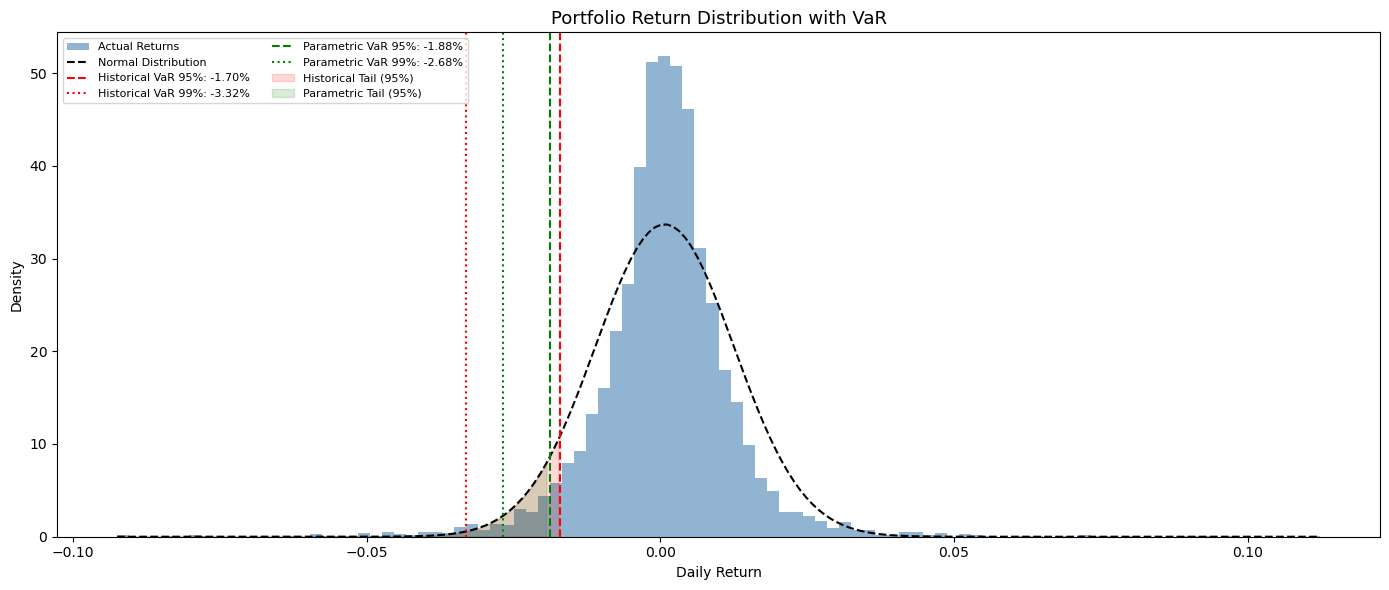

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

# Histogram of actual returns
n, bins, patches = ax.hist(portfolio_returns, bins=100,
    density=True, color='steelblue', alpha=0.6, label='Actual Returns')

# Normal distribution overlay
x    = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 200)
norm = stats.norm.pdf(x, mu, sig)
ax.plot(x, norm, color='black', linewidth=1.5,
    linestyle='--', label='Normal Distribution')

# VaR lines
colors = {'Historical': 'red', 'Parametric': 'green'}

for method, var_dict in [('Historical', hist_var), ('Parametric', param_var)]:
    color = colors[method]
    for cl in CONFIDENCE_LEVELS:
        var = var_dict[cl]
        ax.axvline(var, color=color, linewidth=1.5,
            linestyle='--' if cl == 0.95 else ':',
            label=f'{method} VaR {int(cl*100)}%: {var*100:.2f}%')

# Shade tail regions
ax.fill_between(x, norm,
    where=(x <= hist_var[0.95]),
    color='red', alpha=0.15, label='Historical Tail (95%)')
ax.fill_between(x, norm,
    where=(x <= param_var[0.95]),
    color='green', alpha=0.15, label='Parametric Tail (95%)')

ax.set_title('Portfolio Return Distribution with VaR', fontsize=13)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(False)

plt.tight_layout()
plt.show()

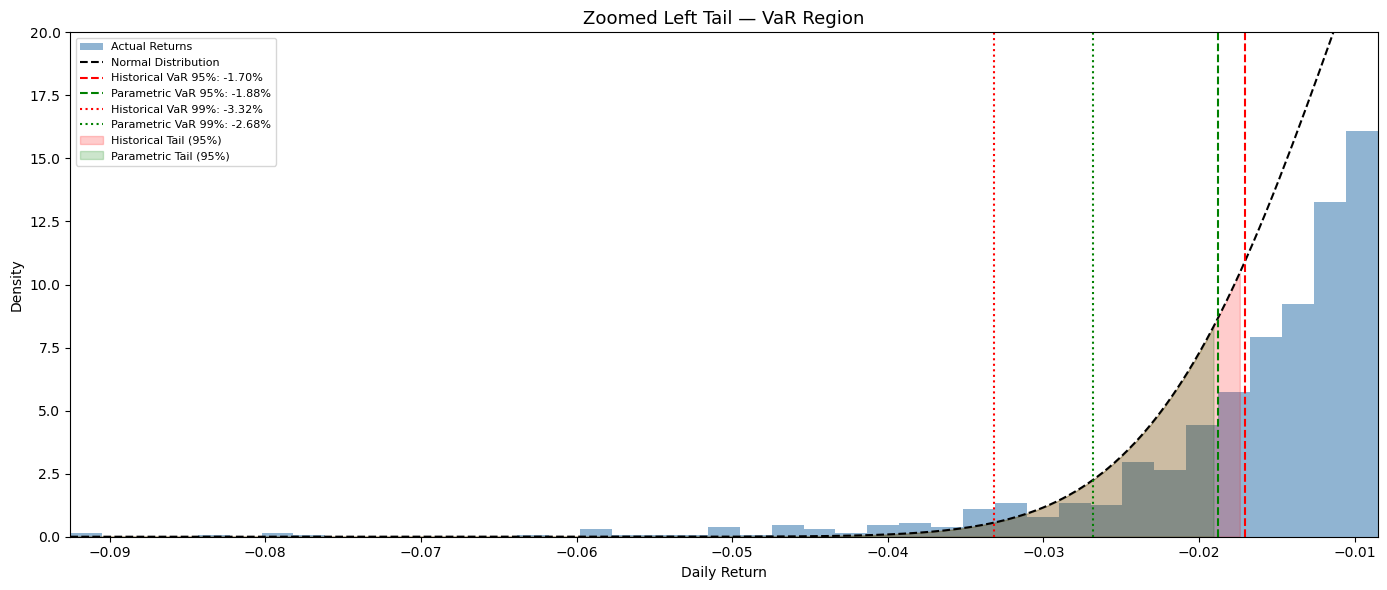

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Find rightmost VaR value (least negative = closest to zero)
all_var_values = [
    hist_var[0.95], hist_var[0.99],
    param_var[0.95], param_var[0.99]
]
rightmost_var = max(all_var_values)  # least negative value
zoom_x_limit  = rightmost_var * 0.5  # extend slightly right of rightmost VaR
zoom_y_limit  = 20

ax.hist(portfolio_returns, bins=100,
    density=True, color='steelblue', alpha=0.6, label='Actual Returns')

x_zoom    = np.linspace(portfolio_returns.min(), zoom_x_limit, 200)
norm_zoom = stats.norm.pdf(x_zoom, mu, sig)
ax.plot(x_zoom, norm_zoom, color='black', linewidth=1.5,
    linestyle='--', label='Normal Distribution')

# VaR lines
for cl in CONFIDENCE_LEVELS:
    ax.axvline(hist_var[cl], color='red', linewidth=1.5,
        linestyle='--' if cl == 0.95 else ':',
        label=f'Historical VaR {int(cl*100)}%: {hist_var[cl]*100:.2f}%')
    ax.axvline(param_var[cl], color='green', linewidth=1.5,
        linestyle='--' if cl == 0.95 else ':',
        label=f'Parametric VaR {int(cl*100)}%: {param_var[cl]*100:.2f}%')

# Shade tail regions
ax.fill_between(x_zoom, norm_zoom,
    where=(x_zoom <= hist_var[0.95]),
    color='red', alpha=0.2, label='Historical Tail (95%)')
ax.fill_between(x_zoom, norm_zoom,
    where=(x_zoom <= param_var[0.95]),
    color='green', alpha=0.2, label='Parametric Tail (95%)')

ax.set_xlim(left=portfolio_returns.min(), right=zoom_x_limit)
ax.set_ylim(bottom=0, top=zoom_y_limit)
ax.set_title('Zoomed Left Tail — VaR Region', fontsize=13)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend(loc='upper left', fontsize=8)
ax.grid(False)

plt.tight_layout()
plt.show()

## Section 6 — Correlation Analysis

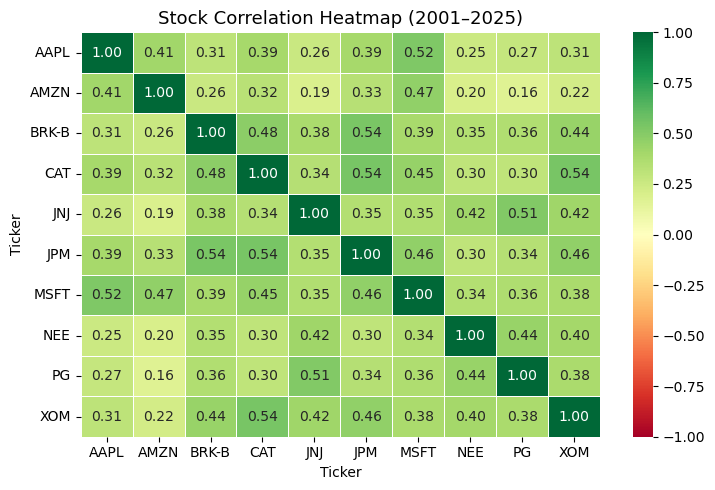

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = simple_returns.corr()

fig, ax = plt.subplots(figsize=(7.5, 5))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1
)

ax.set_title('Stock Correlation Heatmap (2001–2025)', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Weighted average volatility
individual_vols     = simple_returns.std() * np.sqrt(TRADING_DAYS)
weighted_avg_vol    = np.dot(equal_weights, individual_vols)

# Portfolio volatility
port_vol            = portfolio_returns.std() * np.sqrt(TRADING_DAYS)

# Diversification Ratio
diversification_ratio = weighted_avg_vol / port_vol

print(f"Weighted Average Volatility : {weighted_avg_vol*100:.2f}%")
print(f"Portfolio Volatility        : {port_vol*100:.2f}%")
print(f"Diversification Ratio       : {diversification_ratio:.4f}")
print()
if diversification_ratio > 1:
    print(f"→ Diversification is working — combining stocks reduced volatility")
    print(f"→ Portfolio volatility is {((1 - 1/diversification_ratio)*100):.1f}% lower than average individual stock volatility")
else:
    print("→ Little diversification benefit — stocks are highly correlated")

Weighted Average Volatility : 28.47%
Portfolio Volatility        : 18.80%
Diversification Ratio       : 1.5146

→ Diversification is working — combining stocks reduced volatility
→ Portfolio volatility is 34.0% lower than average individual stock volatility


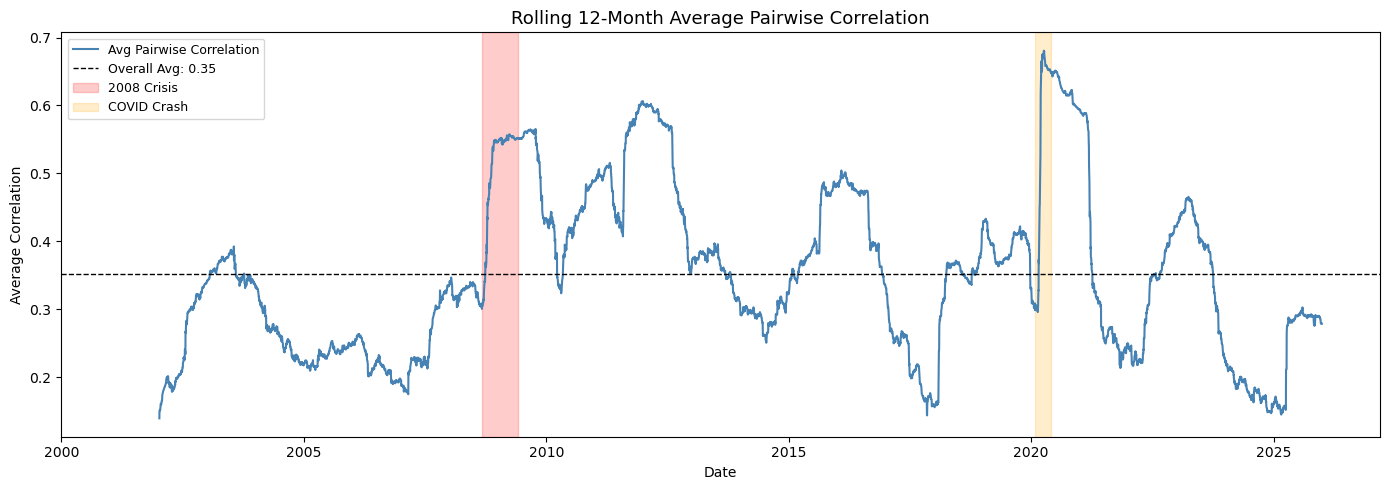

In [24]:
# Rolling 12-month average correlation
rolling_corr = simple_returns.rolling(window=252).corr()

# Extract average pairwise correlation at each date
avg_rolling_corr = []
dates            = []

for date, group in rolling_corr.groupby(level=0):
    # Get upper triangle only (avoid double counting)
    corr_vals = group.values
    upper     = corr_vals[np.triu_indices_from(corr_vals, k=1)]
    avg_rolling_corr.append(upper.mean())
    dates.append(date)

avg_rolling_corr = pd.Series(avg_rolling_corr, index=dates).dropna()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(avg_rolling_corr.index, avg_rolling_corr,
    color='steelblue', linewidth=1.5, label='Avg Pairwise Correlation')
ax.axhline(avg_rolling_corr.mean(), color='black', linewidth=1,
    linestyle='--', label=f'Overall Avg: {avg_rolling_corr.mean():.2f}')

# Shade crisis periods
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
    color='red', alpha=0.2, label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
    color='orange', alpha=0.2, label='COVID Crash')

ax.set_title('Rolling 12-Month Average Pairwise Correlation', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Average Correlation')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(pd.date_range(start='2000-01-01', end='2025-12-31', freq='5YS'))
ax.set_xticklabels([str(y) for y in range(2000, 2026, 5)])
ax.grid(False)

plt.tight_layout()
plt.show()

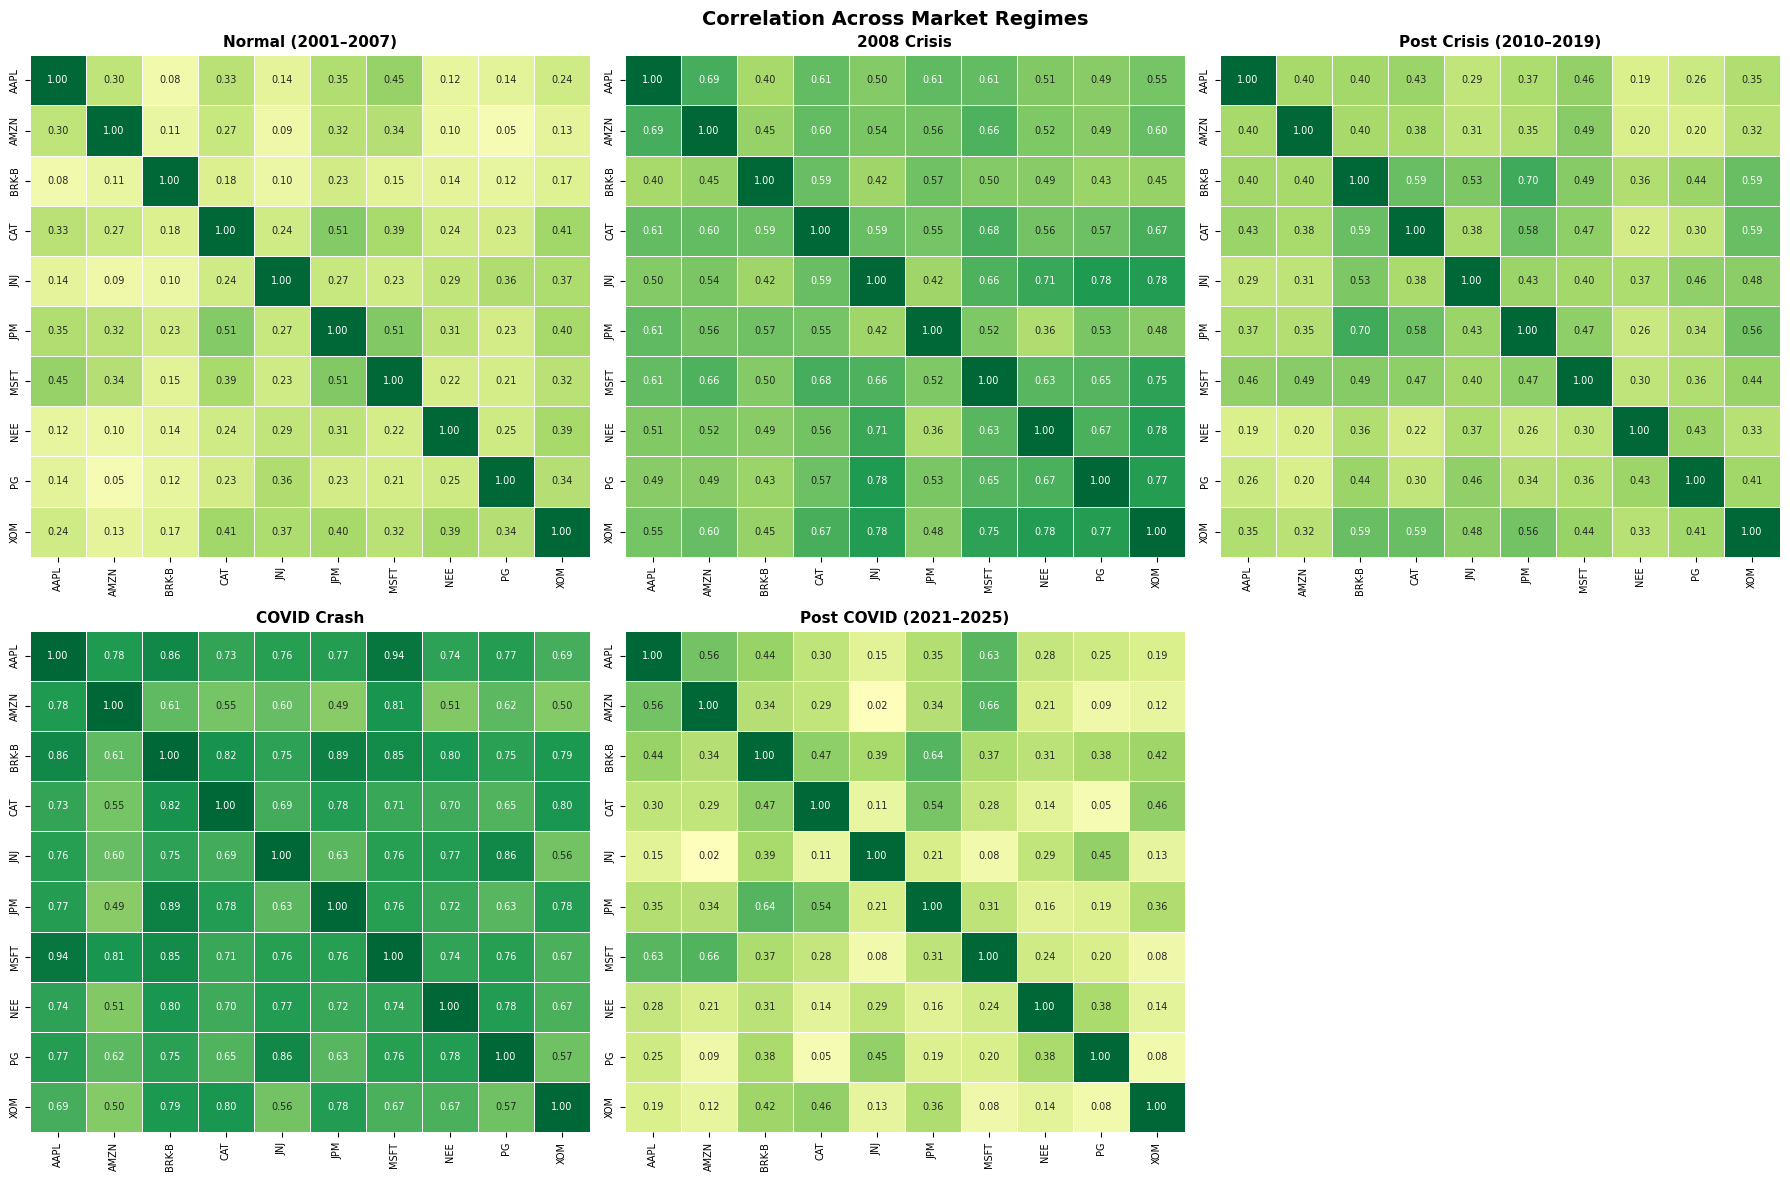

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

periods = {
    'Normal (2001–2007)'     : ('2001-01-01', '2007-12-31'),
    '2008 Crisis'            : ('2008-09-01', '2009-06-01'),
    'Post Crisis (2010–2019)': ('2010-01-01', '2019-12-31'),
    'COVID Crash'            : ('2020-02-01', '2020-06-01'),
    'Post COVID (2021–2025)' : ('2021-01-01', '2025-12-31')
}

for i, (period_name, (start, end)) in enumerate(periods.items()):
    row = i // 3
    col = i % 3
    ax  = axes[row, col]

    period_returns = simple_returns.loc[start:end]
    period_corr    = period_returns.corr()

    sns.heatmap(
        period_corr,
        annot=True, fmt='.2f',
        cmap='RdYlGn', norm=norm,
        linewidths=0.5,
        ax=ax,
        cbar=False,
        annot_kws={'size': 7}
    )
    ax.set_title(period_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=7)

# Hide the empty 6th subplot
axes[1, 2].axis('off')

plt.suptitle('Correlation Across Market Regimes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 — Monte Carlo Simulation

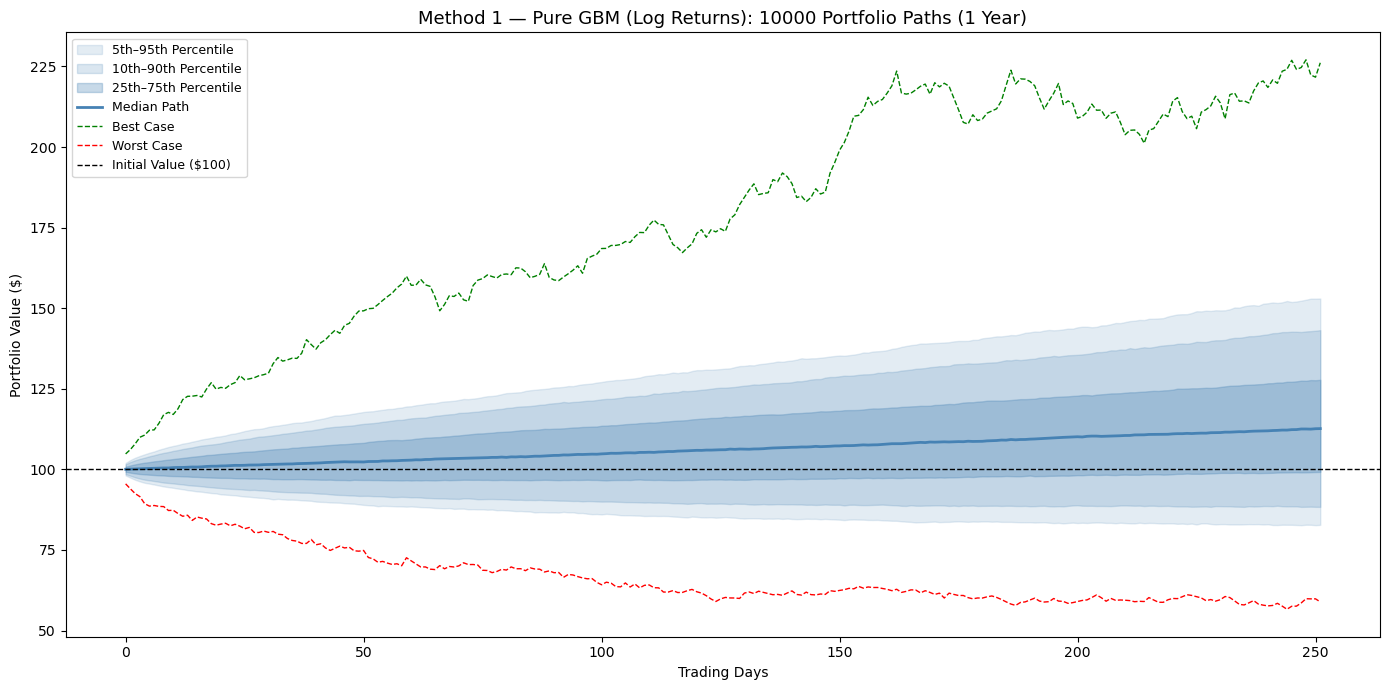

In [26]:
# Method 1 — Pure GBM with Log Returns
np.random.seed(42)

# ── Simulation Parameters ─────────────────────────────────────────────────────
N_SIMULATIONS = 10000
N_DAYS        = 252     # 1 trading year
INITIAL_VALUE = 100     # starting portfolio value ($100)

# ── Inputs from historical data ───────────────────────────────────────────────
portfolio_log_returns = log_returns.dot(equal_weights)
mu_log  = portfolio_log_returns.mean()
sig_log = portfolio_log_returns.std()

# Itô-corrected drift for GBM
drift = mu_log - 0.5 * sig_log**2

# ── Run Simulation ────────────────────────────────────────────────────────────
Z = np.random.standard_normal((N_DAYS, N_SIMULATIONS))
simulated_log_returns_gbm = drift + sig_log * Z

# Cumulative log returns -> portfolio value paths
cumulative_log_returns_gbm = np.cumsum(simulated_log_returns_gbm, axis=0)
price_paths_gbm = INITIAL_VALUE * np.exp(cumulative_log_returns_gbm)

final_values_gbm = price_paths_gbm[-1]

# ── Fan Chart ─────────────────────────────────────────────────────────────────
percentiles = {
    '5th–95th'  : (5,  95,  'steelblue', 0.15),
    '10th–90th' : (10, 90,  'steelblue', 0.20),
    '25th–75th' : (25, 75,  'steelblue', 0.30),
}
fig, ax = plt.subplots(figsize=(14, 7))

for label, (low, high, color, alpha) in percentiles.items():
    ax.fill_between(
        range(N_DAYS),
        np.percentile(price_paths_gbm, low,  axis=1),
        np.percentile(price_paths_gbm, high, axis=1),
        color=color, alpha=alpha, label=f'{label} Percentile'
    )

ax.plot(np.percentile(price_paths_gbm, 50, axis=1),
    color='steelblue', linewidth=2, label='Median Path')
ax.plot(price_paths_gbm.max(axis=1),
    color='green', linewidth=1, linestyle='--', label='Best Case')
ax.plot(price_paths_gbm.min(axis=1),
    color='red', linewidth=1, linestyle='--', label='Worst Case')
ax.axhline(INITIAL_VALUE, color='black', linewidth=1,
    linestyle='--', label=f'Initial Value (${INITIAL_VALUE})')

ax.set_title(f'Method 1 — Pure GBM (Log Returns): {N_SIMULATIONS} Portfolio Paths (1 Year)', fontsize=13)
ax.set_xlabel('Trading Days')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.show()

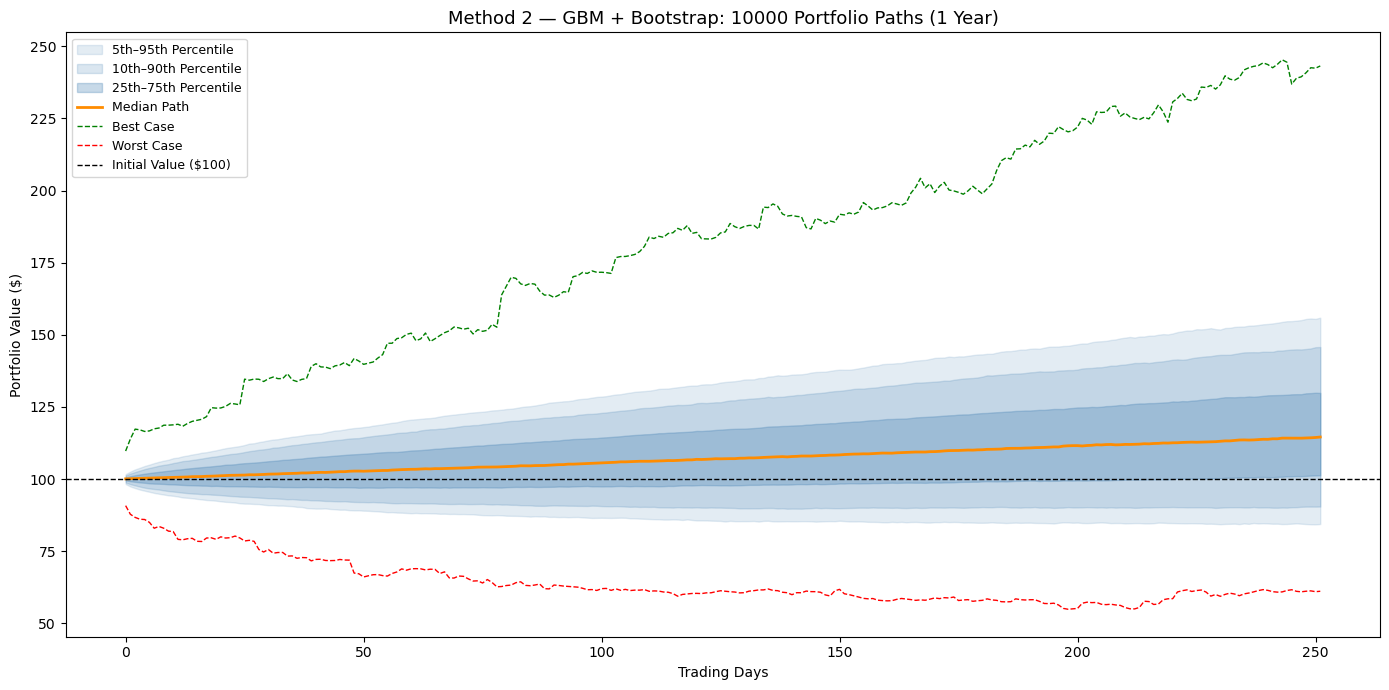

In [27]:
# Method 2 — GBM + Bootstrap (resampled historical log returns)
np.random.seed(42)

# ── Inputs from historical data ───────────────────────────────────────────────
historical_log_returns = portfolio_log_returns.values

# ── Run Simulation ────────────────────────────────────────────────────────────
bootstrap_sample_idx = np.random.randint(0, len(historical_log_returns), size=(N_DAYS, N_SIMULATIONS))
simulated_log_returns_bootstrap = historical_log_returns[bootstrap_sample_idx]

cumulative_log_returns_bootstrap = np.cumsum(simulated_log_returns_bootstrap, axis=0)
price_paths_bootstrap = INITIAL_VALUE * np.exp(cumulative_log_returns_bootstrap)

final_values_bootstrap = price_paths_bootstrap[-1]

# ── Fan Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

for label, (low, high, color, alpha) in percentiles.items():
    ax.fill_between(
        range(N_DAYS),
        np.percentile(price_paths_bootstrap, low,  axis=1),
        np.percentile(price_paths_bootstrap, high, axis=1),
        color=color, alpha=alpha, label=f'{label} Percentile'
    )

ax.plot(np.percentile(price_paths_bootstrap, 50, axis=1),
    color='darkorange', linewidth=2, label='Median Path')
ax.plot(price_paths_bootstrap.max(axis=1),
    color='green', linewidth=1, linestyle='--', label='Best Case')
ax.plot(price_paths_bootstrap.min(axis=1),
    color='red', linewidth=1, linestyle='--', label='Worst Case')
ax.axhline(INITIAL_VALUE, color='black', linewidth=1,
    linestyle='--', label=f'Initial Value (${INITIAL_VALUE})')

ax.set_title(f'Method 2 — GBM + Bootstrap: {N_SIMULATIONS} Portfolio Paths (1 Year)', fontsize=13)
ax.set_xlabel('Trading Days')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.show()

NameError: name 'INITIAL_VALUE_DOLLARS' is not defined

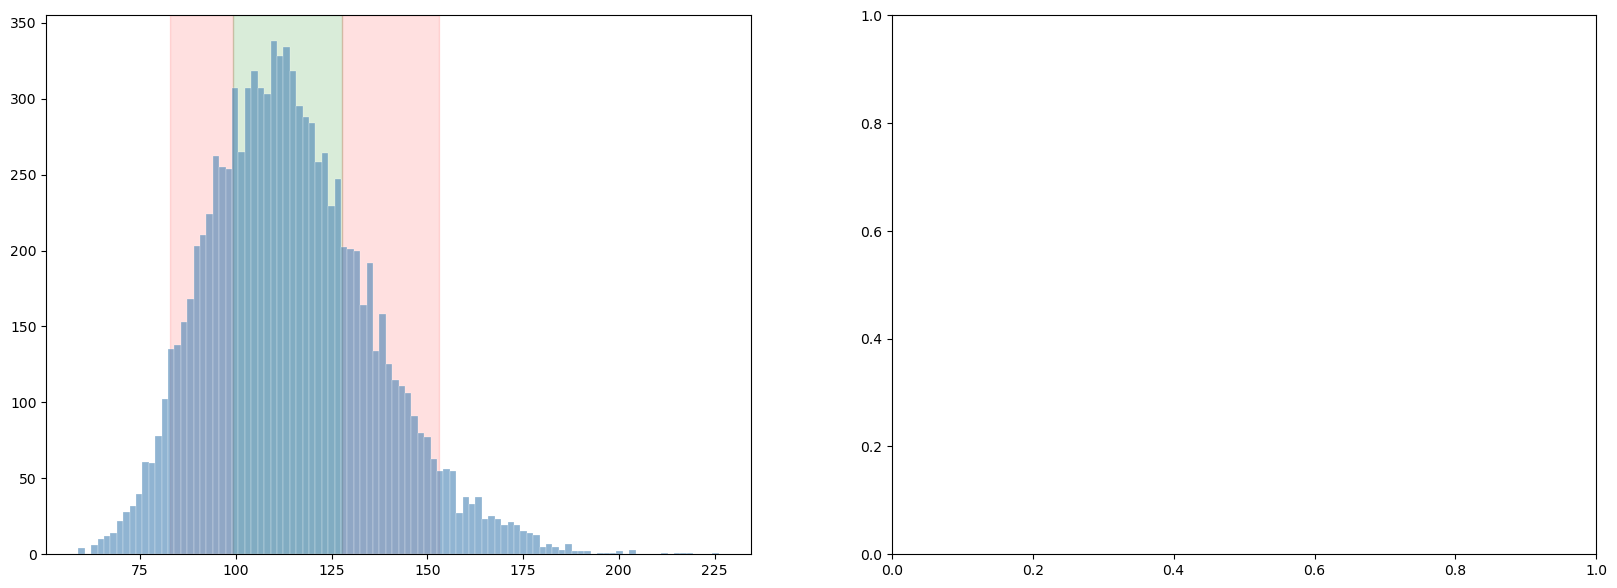

In [28]:
# Distribution of Final Portfolio Values (Method 1 vs Method 2)

def dist_stats(final_values):
    return {
        'mean'  : final_values.mean(),
        'median': np.median(final_values),
        'best'  : final_values.max(),
        'worst' : final_values.min(),
        'p5'    : np.percentile(final_values, 5),
        'p25'   : np.percentile(final_values, 25),
        'p75'   : np.percentile(final_values, 75),
        'p95'   : np.percentile(final_values, 95),
        'prob_loss': (final_values < INITIAL_VALUE).mean() * 100
    }

stats_gbm       = dist_stats(final_values_gbm)
stats_bootstrap = dist_stats(final_values_bootstrap)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
methods = [
    (axes[0], final_values_gbm, stats_gbm, 'Method 1 — Pure GBM (Log Returns)', 'steelblue'),
    (axes[1], final_values_bootstrap, stats_bootstrap, 'Method 2 — GBM + Bootstrap', 'darkorange')
]

for ax, final_values, s, title, color in methods:
    # Percentile bands (separate handles for their own legend box)
    band_handles = []
    band_handles.append(ax.axvspan(s['p5'], s['p25'], color='red', alpha=0.12, label='5th–25th pct'))
    band_handles.append(ax.axvspan(s['p25'], s['p75'], color='green', alpha=0.15, label='25th–75th pct (IQR)'))
    band_handles.append(ax.axvspan(s['p75'], s['p95'], color='red', alpha=0.12, label='75th–95th pct'))

    ax.hist(final_values, bins=100, color=color, alpha=0.6, edgecolor='white', linewidth=0.3)

    # Key vertical lines (separate handles for their own legend box)
    line_handles = []
    line_handles.append(ax.axvline(INITIAL_VALUE, color='black', linewidth=1.5, linestyle='-', label=f'Initial Value: ${INITIAL_VALUE_DOLLARS:.2f}'))
    line_handles.append(ax.axvline(s['mean'], color='blue', linewidth=1.5, linestyle='--', label=f"Mean: ${s['mean']:.2f}"))
    line_handles.append(ax.axvline(s['median'], color='purple', linewidth=1.5, linestyle=':', label=f"Median: ${s['median']:.2f}"))
    line_handles.append(ax.axvline(s['p5'], color='red', linewidth=1.2, linestyle='--', label=f"5th pct: ${s['p5']:.2f}"))
    line_handles.append(ax.axvline(s['p95'], color='darkgreen', linewidth=1.2, linestyle='--', label=f"95th pct: ${s['p95']:.2f}"))
    line_handles.append(ax.axvline(s['best'], color='darkgreen', linewidth=1.5, linestyle='-', alpha=0.8, label=f"Best: ${s['best']:.2f}"))
    line_handles.append(ax.axvline(s['worst'], color='darkred', linewidth=1.5, linestyle='-', alpha=0.8, label=f"Worst: ${s['worst']:.2f}"))

    ax.annotate(f"Prob. of Loss: {s['prob_loss']:.1f}%",
        xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8))

    ax.set_title(f'{title}\n{N_SIMULATIONS} Simulations, {N_DAYS}-Day Horizon', fontsize=12)
    ax.set_xlabel('Final Portfolio Value ($)')
    ax.set_ylabel('Frequency')

    # Two stacked legend boxes, bottom-right
    legend_lines = ax.legend(handles=line_handles, loc='lower right', fontsize=7, title='Value Markers',
                              bbox_to_anchor=(1.0, 0.0))
    ax.add_artist(legend_lines)
    ax.legend(handles=band_handles, loc='lower right', fontsize=7, title='Percentile Bands',
              bbox_to_anchor=(1.0, 0.32))

    ax.grid(False)

plt.tight_layout()
plt.show()

# Summary comparison table — transposed: Metric in columns, Method in rows
dist_summary = pd.DataFrame({
    'Mean ($)'            : [f"${stats_gbm['mean']:.2f}", f"${stats_bootstrap['mean']:.2f}"],
    'Median ($)'           : [f"${stats_gbm['median']:.2f}", f"${stats_bootstrap['median']:.2f}"],
    'Best Case ($)'        : [f"${stats_gbm['best']:.2f}", f"${stats_bootstrap['best']:.2f}"],
    'Worst Case ($)'       : [f"${stats_gbm['worst']:.2f}", f"${stats_bootstrap['worst']:.2f}"],
    '5th Percentile ($)'   : [f"${stats_gbm['p5']:.2f}", f"${stats_bootstrap['p5']:.2f}"],
    '25th Percentile ($)'  : [f"${stats_gbm['p25']:.2f}", f"${stats_bootstrap['p25']:.2f}"],
    '75th Percentile ($)'  : [f"${stats_gbm['p75']:.2f}", f"${stats_bootstrap['p75']:.2f}"],
    '95th Percentile ($)'  : [f"${stats_gbm['p95']:.2f}", f"${stats_bootstrap['p95']:.2f}"],
    'Prob. of Loss (%)'    : [f"{stats_gbm['prob_loss']:.2f}%", f"{stats_bootstrap['prob_loss']:.2f}%"]
}, index=['Method 1 (Pure GBM)', 'Method 2 (Bootstrap)'])

styled_dist_summary = dist_summary.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px')]}])
display(styled_dist_summary)

In [ ]:
# Monte Carlo VaR & CVaR (1-Year Horizon)
CONFIDENCE_LEVELS_MC = [0.95, 0.99]

# Total 1-year return distributions
mc_returns_gbm       = (final_values_gbm - INITIAL_VALUE) / INITIAL_VALUE
mc_returns_bootstrap = (final_values_bootstrap - INITIAL_VALUE) / INITIAL_VALUE

mc_var_gbm, mc_cvar_gbm, mc_var_boot, mc_cvar_boot = {}, {}, {}, {}

for cl in CONFIDENCE_LEVELS_MC:
    # Method 1 — GBM
    var_gbm             = np.percentile(mc_returns_gbm, (1 - cl) * 100)
    mc_var_gbm[cl]       = var_gbm
    mc_cvar_gbm[cl]      = mc_returns_gbm[mc_returns_gbm <= var_gbm].mean()

    # Method 2 — Bootstrap
    var_boot             = np.percentile(mc_returns_bootstrap, (1 - cl) * 100)
    mc_var_boot[cl]       = var_boot
    mc_cvar_boot[cl]      = mc_returns_bootstrap[mc_returns_bootstrap <= var_boot].mean()

mc_var_comparison = pd.DataFrame({
    'Metric'              : ['VaR 95%', 'VaR 99%', 'CVaR 95%', 'CVaR 99%'],
    'Method 1 (GBM)'       : [f"{mc_var_gbm[0.95]*100:.2f}%", f"{mc_var_gbm[0.99]*100:.2f}%",
                               f"{mc_cvar_gbm[0.95]*100:.2f}%", f"{mc_cvar_gbm[0.99]*100:.2f}%"],
    'Method 2 (Bootstrap)': [f"{mc_var_boot[0.95]*100:.2f}%", f"{mc_var_boot[0.99]*100:.2f}%",
                               f"{mc_cvar_boot[0.95]*100:.2f}%", f"{mc_cvar_boot[0.99]*100:.2f}%"]
}).set_index('Metric')

styled_mc_var = mc_var_comparison.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px')]}])
display(styled_mc_var)

In [ ]:
# Updated VaR Comparison Table (Historical, Parametric, Monte Carlo — 1-Year Horizon)
sqrt_t = np.sqrt(TRADING_DAYS)

var_comparison_annualized = pd.DataFrame({
    'Metric'     : ['VaR 95%', 'VaR 99%', 'CVaR 95%', 'CVaR 99%'],
    'Historical' : [f"{hist_var[0.95]*sqrt_t*100:.2f}%", f"{hist_var[0.99]*sqrt_t*100:.2f}%",
                    f"{hist_cvar[0.95]*sqrt_t*100:.2f}%", f"{hist_cvar[0.99]*sqrt_t*100:.2f}%"],
    'Parametric' : [f"{param_var[0.95]*sqrt_t*100:.2f}%", f"{param_var[0.99]*sqrt_t*100:.2f}%",
                    f"{param_cvar[0.95]*sqrt_t*100:.2f}%", f"{param_cvar[0.99]*sqrt_t*100:.2f}%"],
    'Monte Carlo<br> (GBM)'       : [f"{mc_var_gbm[0.95]*100:.2f}%", f"{mc_var_gbm[0.99]*100:.2f}%",
                                  f"{mc_cvar_gbm[0.95]*100:.2f}%", f"{mc_cvar_gbm[0.99]*100:.2f}%"],
    'Monte Carlo<br> (Bootstrap)' : [f"{mc_var_boot[0.95]*100:.2f}%", f"{mc_var_boot[0.99]*100:.2f}%",
                                  f"{mc_cvar_boot[0.95]*100:.2f}%", f"{mc_cvar_boot[0.99]*100:.2f}%"]
}).set_index('Metric')

styled_var_comparison_annualized = var_comparison_annualized.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px')]}])
display(styled_var_comparison_annualized)

## Section 8 — Portfolio Optimization (MPT)

In [ ]:
# MPT Setup, Monte Carlo Cloud + Scipy Optimization
from scipy.optimize import minimize

N_PORTFOLIOS = 20000
n_assets = len(tickers)

mean_returns_ann = simple_returns.mean() * TRADING_DAYS
cov_matrix_ann = simple_returns.cov() * TRADING_DAYS

def portfolio_perf(weights):
    ret = np.dot(weights, mean_returns_ann)
    vol = np.sqrt(weights.T @ cov_matrix_ann @ weights)
    return ret, vol

# ── Monte Carlo Random Weight Simulation (background cloud) ──────────────────
np.random.seed(42)
mc_weights = np.zeros((N_PORTFOLIOS, n_assets))
mc_returns = np.zeros(N_PORTFOLIOS)
mc_vols    = np.zeros(N_PORTFOLIOS)
mc_sharpe  = np.zeros(N_PORTFOLIOS)

for i in range(N_PORTFOLIOS):
    w = np.random.random(n_assets)
    w /= w.sum()
    r, v = portfolio_perf(w)
    mc_weights[i] = w
    mc_returns[i] = r
    mc_vols[i]    = v
    mc_sharpe[i]  = (r - RISK_FREE_RATE) / v

# ── Scipy Optimization: Max Sharpe Ratio Portfolio ────────────────────────────
def neg_sharpe(weights):
    r, v = portfolio_perf(weights)
    return -(r - RISK_FREE_RATE) / v

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds      = tuple((0, 1) for _ in range(n_assets))
init_guess  = np.array([1 / n_assets] * n_assets)

opt_max_sharpe = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
weights_max_sharpe = opt_max_sharpe.x
ret_max_sharpe, vol_max_sharpe = portfolio_perf(weights_max_sharpe)
sharpe_max_sharpe = (ret_max_sharpe - RISK_FREE_RATE) / vol_max_sharpe

# ── Scipy Optimization: Minimum Variance Portfolio ────────────────────────────
def portfolio_vol(weights):
    return portfolio_perf(weights)[1]

opt_min_var = minimize(portfolio_vol, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
weights_min_var = opt_min_var.x
ret_min_var, vol_min_var = portfolio_perf(weights_min_var)
sharpe_min_var = (ret_min_var - RISK_FREE_RATE) / vol_min_var

In [ ]:
# Unified Efficient Frontier Chart
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(mc_vols * 100, mc_returns * 100, c=mc_sharpe, cmap='viridis',
    s=15, alpha=0.4, zorder=2)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sharpe Ratio', fontsize=10)

# Max Sharpe Ratio Portfolio — star marker
ax.scatter(vol_max_sharpe * 100, ret_max_sharpe * 100, marker='*', s=200, color='red',
    edgecolors='black', linewidth=1, zorder=5, label=f'Max Sharpe (SR: {sharpe_max_sharpe:.2f})')

# Min Variance Portfolio — diamond marker
ax.scatter(vol_min_var * 100, ret_min_var * 100, marker='D', s=75, color='blue',
    edgecolors='black', linewidth=1, zorder=5, label=f'Min Variance (SR: {sharpe_min_var:.2f})')

# Equal Weight Portfolio for reference
eq_ret, eq_vol = portfolio_perf(equal_weights)
ax.scatter(eq_vol * 100, eq_ret * 100, marker='o', s=75, color='orange',
    edgecolors='black', linewidth=1, zorder=5, label='Equal Weight')

# Efficient Frontier Curve
target_returns = np.linspace(ret_min_var, ret_max_sharpe * 1.05, 50)
efficient_vols  = []

for target in target_returns:
    frontier_constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, target=target: portfolio_perf(w)[0] - target}
    )
    result = minimize(portfolio_vol, init_guess, method='SLSQP',
        bounds=bounds, constraints=frontier_constraints)
    efficient_vols.append(result.fun if result.success else np.nan)

efficient_vols = np.array(efficient_vols)

ax.plot(efficient_vols * 100, target_returns * 100, color='black', linestyle='-',
    linewidth=2, zorder=4, label='Efficient Frontier')

ax.set_title(f'Efficient Frontier — {N_PORTFOLIOS} Simulated Portfolios (Long-Only)', fontsize=13)
ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# Portfolio allocation (%) by stock
allocation_df = pd.DataFrame({
    'Equal Weighted'  : equal_weights * 100,
    'Minimum Variance': weights_min_var * 100,
    'Maximum Sharpe'  : weights_max_sharpe * 100
}, index=tickers).T
allocation_df.index.name = 'Portfolio'

allocation_df = allocation_df.round(2).astype(str) + '%'

styled_allocation = allocation_df.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px')]}])

# Unified Comparison Table — Equal Weight vs Min Variance vs Max Sharpe
mpt_comparison = pd.DataFrame({
    'Metric': ['Expected Return (%)', 'Annualized Volatility (%)', 'Sharpe Ratio'],
    'Equal Weighted'    : [f'{eq_ret*100:.2f}%', f'{eq_vol*100:.2f}%', f'{(eq_ret - RISK_FREE_RATE)/eq_vol:.2f}'],
    'Minimum Variance'  : [f'{ret_min_var*100:.2f}%', f'{vol_min_var*100:.2f}%', f'{sharpe_min_var:.2f}'],
    'Maximum Sharpe'    : [f'{ret_max_sharpe*100:.2f}%', f'{vol_max_sharpe*100:.2f}%', f'{sharpe_max_sharpe:.2f}']
}).set_index('Metric')

styled_mpt_comparison = mpt_comparison.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px')]}])

display(HTML(f'<div style="display:flex;flex-direction:row;align-items:flex-start;gap:20px;">'
             f'{styled_allocation.to_html()}'
             f'{styled_mpt_comparison.to_html()}</div>'))

## Section 9 — Summary Dashboard & Risk Comparison

In [ ]:
# Reusable Risk Function (Historical, Parametric, GBM MC, Bootstrap MC)
def compute_full_risk_profile(weight_vector, label):
    port_ret = simple_returns.dot(weight_vector)
    port_log_ret = log_returns.dot(weight_vector)

    mu, sig = port_ret.mean(), port_ret.std()
    mu_log, sig_log = port_log_ret.mean(), port_log_ret.std()
    drift = mu_log - 0.5 * sig_log**2
    sqrt_t = np.sqrt(TRADING_DAYS)

    results = {}
    for cl in [0.95, 0.99]:
        ci_label = f'{int(cl*100)}%'

        h_var = np.percentile(port_ret, (1 - cl) * 100)
        h_cvar = port_ret[port_ret <= h_var].mean()
        results[(ci_label, 'VaR', 'Historical')]  = h_var * sqrt_t * 100
        results[(ci_label, 'CVaR', 'Historical')] = h_cvar * sqrt_t * 100

        p_var = mu + sig * stats.norm.ppf(1 - cl)
        p_cvar = mu - sig * stats.norm.pdf(stats.norm.ppf(cl)) / (1 - cl)
        results[(ci_label, 'VaR', 'Parametric')]  = p_var * sqrt_t * 100
        results[(ci_label, 'CVaR', 'Parametric')] = p_cvar * sqrt_t * 100

    np.random.seed(42)
    Z = np.random.standard_normal((N_DAYS, N_SIMULATIONS))
    sim_log_gbm = drift + sig_log * Z
    final_gbm = INITIAL_VALUE * np.exp(np.cumsum(sim_log_gbm, axis=0))[-1]
    mc_ret_gbm = (final_gbm - INITIAL_VALUE) / INITIAL_VALUE

    hist_log = port_log_ret.values
    boot_idx = np.random.randint(0, len(hist_log), size=(N_DAYS, N_SIMULATIONS))
    sim_log_boot = hist_log[boot_idx]
    final_boot = INITIAL_VALUE * np.exp(np.cumsum(sim_log_boot, axis=0))[-1]
    mc_ret_boot = (final_boot - INITIAL_VALUE) / INITIAL_VALUE

    for cl in [0.95, 0.99]:
        ci_label = f'{int(cl*100)}%'

        v_gbm = np.percentile(mc_ret_gbm, (1 - cl) * 100)
        c_gbm = mc_ret_gbm[mc_ret_gbm <= v_gbm].mean()
        results[(ci_label, 'VaR', 'MC-GBM')]  = v_gbm * 100
        results[(ci_label, 'CVaR', 'MC-GBM')] = c_gbm * 100

        v_boot = np.percentile(mc_ret_boot, (1 - cl) * 100)
        c_boot = mc_ret_boot[mc_ret_boot <= v_boot].mean()
        results[(ci_label, 'VaR', 'MC-Bootstrap')]  = v_boot * 100
        results[(ci_label, 'CVaR', 'MC-Bootstrap')] = c_boot * 100

    return pd.Series(results, name=label)

risk_eq   = compute_full_risk_profile(equal_weights, 'Equal Weighted')
risk_minv = compute_full_risk_profile(weights_min_var, 'Minimum Variance')
risk_maxs = compute_full_risk_profile(weights_max_sharpe, 'Maximum Sharpe')

master_risk_matrix = pd.concat([risk_eq, risk_minv, risk_maxs], axis=1).round(2)
master_risk_matrix.index = pd.MultiIndex.from_tuples(master_risk_matrix.index, names=['Confidence', 'Metric', 'Method'])

# Enforce correct nested order: Confidence -> Metric -> Method
confidence_order = ['95%', '99%']
metric_order      = ['VaR', 'CVaR']
method_order      = ['Historical', 'Parametric', 'MC-GBM', 'MC-Bootstrap']

ordered_index = pd.MultiIndex.from_tuples(
    [(c, m, meth) for c in confidence_order for m in metric_order for meth in method_order],
    names=['Confidence', 'Metric', 'Method']
)
master_risk_matrix = master_risk_matrix.reindex(ordered_index)
master_risk_matrix = master_risk_matrix.map(lambda x: f'{x:.2f}%')

In [ ]:
# Master Risk Dashboard Table
master_risk_matrix_T = master_risk_matrix.T

styled_master_risk = master_risk_matrix_T.style\
    .set_properties(**{'background-color': '#d6eaf8', 'color': '#1a252f', 'border': '1px solid white', 'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'table', 'props': [('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '6px'),
                                      ('text-align', 'center'), ('border', '1px solid white')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        # Vertical separators (normal weight, matching others)
        {'selector': 'th.col4, td.col4', 'props': [('border-left', '1px solid white')]},
        {'selector': 'th.col8, td.col8', 'props': [('border-left', '1px solid white')]},
        {'selector': 'th.col12, td.col12', 'props': [('border-left', '1px solid white')]},
    ])
display(HTML(styled_master_risk.to_html()))

In [ ]:
# Equal Weight vs Min Variance vs Max Sharpe — Performance Comparison
display(HTML(f'<div style="display:flex;flex-direction:row;align-items:flex-start;gap:20px;">'
             f'{styled_allocation.to_html()}'
             f'{styled_mpt_comparison.to_html()}</div>'))

In [ ]:
# Portfolio Allocation — Stacked Bar (by Sector) + Heatmap (by Stock)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

alloc_matrix = pd.DataFrame({
    'Equal Weighted'  : equal_weights * 100,
    'Minimum Variance': weights_min_var * 100,
    'Maximum Sharpe'  : weights_max_sharpe * 100
}, index=tickers)

# ── Aggregate allocation by sector ────────────────────────────────────────────
alloc_matrix['Sector'] = [stocks[t] for t in alloc_matrix.index]
sector_alloc = alloc_matrix.groupby('Sector').sum()

# ── Left: Horizontal Stacked Bar by Sector (muted palette) ───────────────────
ax_bar = axes[0]
portfolios = ['Equal Weighted', 'Minimum Variance', 'Maximum Sharpe']
sectors = sector_alloc.index.tolist()
colors_stack = plt.cm.viridis(np.linspace(0, 1, len(sectors)))

left = np.zeros(len(portfolios))
for i, sector in enumerate(sectors):
    values = sector_alloc.loc[sector, portfolios].values
    ax_bar.barh(portfolios, values, left=left, color=colors_stack[i], label=sector, edgecolor='white', linewidth=0.5)
    left += values

ax_bar.set_title('Portfolio Allocation Breakdown by Sector', fontsize=13)
ax_bar.set_xlabel('Allocation (%)')
ax_bar.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, title='Sector')
ax_bar.grid(False)

# ── Right: Heatmap by Stock (unchanged) ───────────────────────────────────────
ax_heat = axes[1]
sns.heatmap(alloc_matrix[portfolios], annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
    ax=ax_heat, cbar_kws={'label': 'Allocation (%)'})
ax_heat.set_title('Allocation (%) — Stock vs Portfolio', fontsize=13)
ax_heat.set_xlabel('Portfolio')
ax_heat.set_ylabel('Stock')

plt.suptitle('Final Portfolio Allocation Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways
- Equal Weight offers simplicity and diversification but is not risk/return-optimal.
- Minimum Variance minimizes volatility, at some return trade-off.
- Maximum Sharpe delivers the best risk-adjusted return (highest Sharpe Ratio) among the three.
- Monte Carlo (Bootstrap) captures fat tails/skew better than GBM — expect its VaR/CVaR to be more conservative.
- Historical & Parametric VaR (annualized via sqrt-time) provide a baseline sanity check against Monte Carlo horizon estimates.